# SPARROW DLPFC Example: Sample 151673

This tutorial runs a compact single-sample SPARROW workflow for DLPFC Visium sample `151673`: clustering, inspection of precomputed deconvolution output, and a minimal spatial A-to-I analysis. It is intended as the lightweight GitHub example; the full reproduction notebooks and large data files should be archived separately with the dataset.

All figures are displayed in the notebook only; no files are written.

Results are displayed inline. This notebook does not export figures or result files.


## Setup

The example expects a local copy of the sample data directory containing the 10x Visium matrix, spatial image files, manual layer labels, precomputed deconvolution output, and the A-to-I AnnData object. Set `SPARROW_DLPFC_151673_DIR` to that directory, or edit `SAMPLE_DIR` below.

The optional mclust section uses the R installation inside the active `sparrow` conda environment through `rpy2`.


In [1]:
from pathlib import Path
import json
import os
import sys
import warnings

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import torch

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Make conda-env R visible to rpy2 before importing SPARROW utilities.
R_HOME = Path(sys.prefix) / "lib" / "R"
if not R_HOME.exists():
    R_HOME = Path(sys.prefix) / "Lib" / "R"
if not R_HOME.exists():
    raise RuntimeError("Conda-environment R was not found. Install r-base in the active SPARROW environment.")

R_DLL_DIRS = [
    Path(sys.prefix) / "Library" / "mingw-w64" / "bin",
    Path(sys.prefix) / "Library" / "bin",
    R_HOME / "bin" / "x64",
    R_HOME / "bin",
    Path(sys.prefix) / "Scripts",
]
for dll_dir in R_DLL_DIRS:
    if dll_dir.exists() and hasattr(os, "add_dll_directory"):
        os.add_dll_directory(str(dll_dir))

os.environ["R_HOME"] = str(R_HOME)
os.environ["PATH"] = os.pathsep.join(str(p) for p in R_DLL_DIRS if p.exists()) + os.pathsep + os.environ.get("PATH", "")

from sparrow import SPARROW
from sparrow import atoi
from sparrow.preprocess import *
from sparrow.utils import *

warnings.filterwarnings("ignore")

# Display results only; disable automatic figure export from earlier sessions.
sc.settings.autosave = False
sc.settings.autoshow = True
if "_SPARROW_ORIGINAL_PLT_SHOW" in globals():
    plt.show = _SPARROW_ORIGINAL_PLT_SHOW


SAMPLE_ID = "151673"
SAMPLE_DIR = Path(os.environ.get("SPARROW_DLPFC_151673_DIR", "D:/data/SPARROW_data/DLPFC/151673"))
GROUP_KEY = "ground_truth"
RANDOM_SEED = 42

H5_PATH = SAMPLE_DIR / "filtered_feature_bc_matrix.h5"
TISSUE_POSITIONS_PATH = SAMPLE_DIR / "spatial" / "tissue_positions_list.csv"
SCALEFACTORS_PATH = SAMPLE_DIR / "spatial" / "scalefactors_json.json"
HE_IMAGE_PATH = SAMPLE_DIR / "spatial" / "tissue_hires_image.png"
LABEL_PATH = SAMPLE_DIR / f"cluster_labels_{SAMPLE_ID}.csv"
DECONV_PATH = SAMPLE_DIR / "adata_obs_SPARROW.csv"
ATOI_PATH = SAMPLE_DIR / "adata_ai.h5ad"

ADAR_GENES = ("ADAR", "ADARB1", "ADARB2")
RECURRENT_SV_SITE = "1_634012"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Using R_HOME: {os.environ['R_HOME']}")
print(f"Sample directory: {SAMPLE_DIR}")


EXTERNAL_ANNOTATION_PATHS = {
    "miRBase": {"path": r"D:\data\SPARROW_data\Annotation\miRBase\hsa.gff3", "type": "gff3"},
    "miRGeneDB": {"path": r"D:\data\SPARROW_data\Annotation\miRGeneDB\hsa-all.bed", "type": "bed"},
    "RepeatMasker/Alu": {"path": r"D:\data\SPARROW_data\Annotation\RepeatMasker\rmsk.txt.gz", "type": "repeatmasker"},
    "REDIportal": {"path": r"D:\data\SPARROW_data\Annotation\REDIportal\TABLE1_hg38_v3.txt", "type": "rediportal"},
    "TargetScan gene information": {
        "path": r"D:\data\SPARROW_data\Annotation\TargetScan\Gene_info.txt.zip",
        "type": "gene",
        "gene_col": "Gene symbol",
        "name_col": "Gene description",
        "filters": {"Species ID": "9606"},
        "scope": "human_gene_reference",
    },
    "TargetScan miRNA families": {
        "path": r"D:\data\SPARROW_data\Annotation\TargetScan\miR_Family_Info.txt.zip",
        "type": "catalog",
        "scope": "human_miRNA_family_reference_catalog",
    },
    "TargetScan predictions": {
        "path": r"D:\data\SPARROW_data\Annotation\TargetScan\Summary_Counts.all_predictions.txt.zip",
        "type": "gene",
        "gene_col": "Gene Symbol",
        "name_col": "Representative miRNA",
        "filters": {"Species ID": "9606"},
        "scope": "human_gene_miRNA_prediction",
    },
    "RBP": {
        "path": r"D:\data\SPARROW_data\Annotation\RBP\ENCODE_eCLIP_GRCh38_bed",
        "type": "bed",
        "name_regex": r"_IDR(?:$|_)",
        "prefilter_files_by_first_name": True,
        "label_parser": "rbp",
        "deduplicate_labels_per_site": True,
        "scope": "ENCODE_eCLIP_IDR_peaks_deduplicated_by_RBP",
    },
}

Using device: cuda
Using R_HOME: D:\Anaconda3\envs\sparrow\lib\R
Sample directory: D:\data\SPARROW_data\DLPFC\151673


## Data Files

The expected sample directory contains `filtered_feature_bc_matrix.h5`, the `spatial/` folder from Space Ranger, `cluster_labels_151673.csv`, `adata_obs_SPARROW.csv`, and `adata_ai.h5ad`. The full dataset is not stored in this repository because it is large; use the archived data release associated with the project.


## Load Spatial Expression Data

Load the 10x Visium matrix, attach tissue coordinates, and add manual DLPFC layer labels as `ground_truth`.


In [2]:
adata = sc.read_10x_h5(H5_PATH)
adata.X = adata.X.astype(np.float32)

tissue_positions = pd.read_csv(TISSUE_POSITIONS_PATH, header=None)
tissue_positions.columns = ["barcode", "in_tissue", "x_array", "y_array", "x_pixel", "y_pixel"]
tissue_positions = tissue_positions.set_index("barcode")
tissue_positions = tissue_positions.reindex(adata.obs_names)

adata.obs["in_tissue"] = tissue_positions["in_tissue"].values
adata.obs["x_array"] = tissue_positions["x_array"].values
adata.obs["y_array"] = tissue_positions["y_array"].values
adata.obs["x_pixel"] = tissue_positions["x_pixel"].values
adata.obs["y_pixel"] = tissue_positions["y_pixel"].values
adata.obs[["x_pixel", "y_pixel"]] = adata.obs[["x_pixel", "y_pixel"]].fillna(0)
adata.obsm["spatial"] = adata.obs[["x_pixel", "y_pixel"]].to_numpy(dtype=float)

label_df = pd.read_csv(LABEL_PATH)
label_df["barcode"] = label_df["key"].astype(str).str.split("_", n=1).str[1]
label_df = label_df.set_index("barcode")
adata.obs[GROUP_KEY] = adata.obs_names.map(label_df[GROUP_KEY])
adata.obs[GROUP_KEY] = adata.obs[GROUP_KEY].replace(["nan", "None", "NA", "null", ""], np.nan)

print(adata)
display(adata.obs[GROUP_KEY].value_counts(dropna=False).to_frame("n_spots"))


AnnData object with n_obs × n_vars = 3639 × 33538
    obs: 'in_tissue', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'ground_truth'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'


,n_spots
Layer_3,989
Layer_6,692
Layer_5,673
WM,513
Layer_1,273
Layer_2,253
Layer_4,218
NaN,28


The clustering step trains a SPARROW model for this sample. Runtime depends on hardware and is fastest with CUDA; for a quick smoke test, reduce `epochs` in the next cell.


## Clustering

Train SPARROW, then run Leiden and mclust clustering on the learned embedding. ARI is used for parameter selection because this tutorial sample includes layer annotations.


In [3]:
model = SPARROW(
    adata=adata,
    device=device,
    epochs=1200,
    random_seed=RANDOM_SEED,
    learning_rate=0.001,
    alpha=10,
    beta=1,
    dynamic_graph=True,
    dynamic_start_epoch=200,
    dynamic_update_interval=100,
    dynamic_k=10,
)
adata = model.train(mask_rate=0.2)


Mode: Clustering/Refinement.
Constructing features...
- Processing Gene Expression (Top 3000)...
Preprocessing gene expression: selecting top 3000 genes...
Final Input: [Gene] | Dimension: (3639, 3002)
Begin to train SPARROW [MAE (Rate=0.2)]...
Dynamic Graph: ENABLED | Start Ep: 200 | Interval: 100
Strategy: Spatial-feature fusion with preserved spatial prior


100%|██████████████████████████████████████████████████████████████████████████████| 1200/1200 [05:49<00:00,  3.44it/s]


Optimization finished!


### Leiden Clustering


In [4]:
n_clusters = 7
adata, best_n_leiden = clustering_auto(
    adata,
    n_clusters=n_clusters,
    n_components=[30, 25, 20, 15, 10],
    method="leiden",
    eval_metric="sc",
    refinement=True,
    start=0.1,
    end=1.0,
    increment=0.01,
)
adata.obs["SPARROW_leiden"] = adata.obs["domain"].astype(str)

leiden_metrics = {
    "ARI": adjusted_rand_score(adata.obs[GROUP_KEY].dropna(), adata.obs.loc[adata.obs[GROUP_KEY].notna(), "SPARROW_leiden"]),
    "NMI": normalized_mutual_info_score(adata.obs[GROUP_KEY].dropna(), adata.obs.loc[adata.obs[GROUP_KEY].notna(), "SPARROW_leiden"]),
}
print(f"Best n_components for Leiden: {best_n_leiden}")
print(f"Leiden ARI: {leiden_metrics['ARI']:.4f}")
print(f"Leiden NMI: {leiden_metrics['NMI']:.4f}")


Starting auto-clustering (method=leiden, metric=sc)
  [Search] Linear reverse search for k=7...
  [n=30] Res=0.7800 | K=6 | SC=0.0470
  [Search] Linear reverse search for k=7...
  [n=25] Res=0.6700 | K=6 | SC=0.0380
  [Search] Linear reverse search for k=7...
  [n=20] Res=0.6500 | K=7 | SC=-0.0041
  [Search] Linear reverse search for k=7...
  [n=15] Res=0.5800 | K=6 | SC=0.0261
  [Search] Linear reverse search for k=7...
  [n=10] Res=0.5000 | K=7 | SC=0.0027

>>> Winner: n_components=30, SC=0.0470
Best n_components for Leiden: 30
Leiden ARI: 0.5221
Leiden NMI: 0.6469


### mclust Clustering


In [5]:
import rpy2.robjects as robjects
from rpy2.robjects.packages import importr, isinstalled

print(f"rpy2 is using {robjects.r('R.version.string')[0]}")
if not isinstalled("mclust"):
    raise RuntimeError("The R package 'mclust' is not installed in the active SPARROW conda environment.")
importr("mclust")

adata, best_n_mclust = clustering_auto(
    adata,
    n_clusters=n_clusters,
    n_components=[30, 25, 20, 15, 10],
    method="mclust",
    eval_metric="sc",
    refinement=True,
    start=0.1,
    end=1.0,
    increment=0.01,
)
adata.obs["SPARROW_mclust"] = adata.obs["domain"].astype(str)

mclust_metrics = {
    "ARI": adjusted_rand_score(adata.obs[GROUP_KEY].dropna(), adata.obs.loc[adata.obs[GROUP_KEY].notna(), "SPARROW_mclust"]),
    "NMI": normalized_mutual_info_score(adata.obs[GROUP_KEY].dropna(), adata.obs.loc[adata.obs[GROUP_KEY].notna(), "SPARROW_mclust"]),
}
print(f"Best n_components for mclust: {best_n_mclust}")
print(f"mclust ARI: {mclust_metrics['ARI']:.4f}")
print(f"mclust NMI: {mclust_metrics['NMI']:.4f}")


rpy2 is using R version 4.0.5 (2021-03-31)
Starting auto-clustering (method=mclust, metric=sc)
  [n=30] Res=N/A | K=7 | SC=-0.0403
  [n=25] Res=N/A | K=6 | SC=-0.0547
  [n=20] Res=N/A | K=6 | SC=0.0518
  [n=15] Res=N/A | K=6 | SC=-0.0566
  [n=10] Res=N/A | K=6 | SC=0.0496

>>> Winner: n_components=20, SC=0.0518
Best n_components for mclust: 20
mclust ARI: 0.6704
mclust NMI: 0.7497


### Clustering Visualization With H&E Background

The H&E image is shown underneath the ground truth, Leiden, and mclust labels.


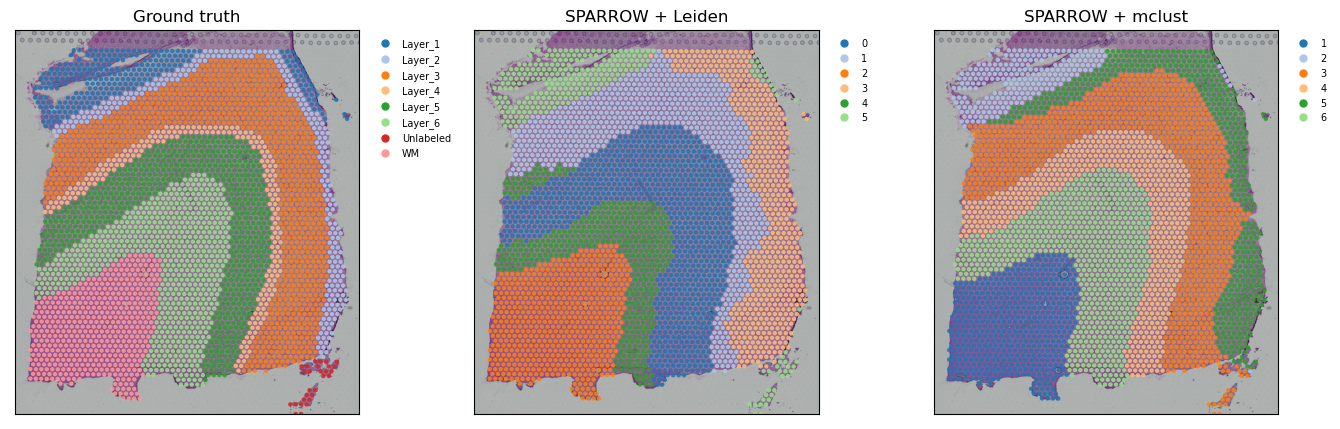

,ARI,NMI
SPARROW + Leiden,0.522058,0.646866
SPARROW + mclust,0.670384,0.749684


In [6]:
he_img = plt.imread(HE_IMAGE_PATH)
with open(SCALEFACTORS_PATH, "r") as f:
    hires_scale = json.load(f).get("tissue_hires_scalef", 1.0)

coords_he = adata.obs[["x_pixel", "y_pixel"]].to_numpy(dtype=float) * hires_scale
coords_he = coords_he[:, [1, 0]]
plot_keys = [GROUP_KEY, "SPARROW_leiden", "SPARROW_mclust"]
plot_titles = ["Ground truth", "SPARROW + Leiden", "SPARROW + mclust"]

x_min, x_max = np.nanpercentile(coords_he[:, 0], [0.5, 99.5])
y_min, y_max = np.nanpercentile(coords_he[:, 1], [0.5, 99.5])
pad = 80

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))
for ax, key, title in zip(axes, plot_keys, plot_titles):
    values = adata.obs[key].astype("object").fillna("Unlabeled").astype("category")
    palette = sns.color_palette("tab20", n_colors=max(len(values.cat.categories), 1))
    color_map = dict(zip(values.cat.categories, palette))
    point_colors = [color_map[v] for v in values]

    ax.imshow(he_img)
    ax.scatter(coords_he[:, 0], coords_he[:, 1], c=point_colors, s=10, linewidths=0, alpha=0.88)
    ax.set_title(title)
    ax.set_xlim(max(x_min - pad, 0), min(x_max + pad, he_img.shape[1]))
    ax.set_ylim(min(y_max + pad, he_img.shape[0]), max(y_min - pad, 0))
    ax.set_xticks([])
    ax.set_yticks([])
    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", color=color_map[c], label=str(c), markersize=5)
        for c in values.cat.categories
    ]
    ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=7)

plt.tight_layout()
plt.show()

cluster_metrics = pd.DataFrame([leiden_metrics, mclust_metrics], index=["SPARROW + Leiden", "SPARROW + mclust"])
display(cluster_metrics)


## Deconvolution

This example reads the precomputed SPARROW deconvolution output for sample `151673` and displays the major cell-type proportions. The same deconvolution table is reused later in the A-to-I model.


In [7]:
df_deconv_raw = pd.read_csv(DECONV_PATH, index_col=0)
metadata_cols = {"in_tissue", "x_array", "y_array", "x_pixel", "y_pixel", "array_row", "array_col", GROUP_KEY, "domain"}
numeric_cols = df_deconv_raw.select_dtypes(include=[np.number]).columns.tolist()
celltype_cols = [c for c in numeric_cols if c not in metadata_cols]
celltype_cols = [c for c in celltype_cols if df_deconv_raw[c].notna().any() and df_deconv_raw[c].sum() > 0]

df_deconv = df_deconv_raw[celltype_cols].copy()
df_deconv = df_deconv.div(df_deconv.sum(axis=1).replace(0, np.nan), axis=0)

top_celltypes = df_deconv.mean(axis=0).sort_values(ascending=False).head(6).index.tolist()
common = adata.obs_names.intersection(df_deconv.index)
for col in top_celltypes:
    adata.obs[col] = np.nan
    adata.obs.loc[common, col] = df_deconv.loc[common, col].astype(float)

print("Precomputed deconvolution table:", df_deconv_raw.shape)
print("Cell-type proportion columns:", len(celltype_cols))
display(df_deconv[top_celltypes].describe().T)


Precomputed deconvolution table: (3639, 38)
Cell-type proportion columns: 33


,count,mean,std,min,25%,50%,75%,max
Ex_10_L2_4,3639.0,0.206251,0.212261,0.004052,0.046830,0.112653,0.312862,0.861294
Ex_3_L4_5,3639.0,0.110968,0.080021,0.000082,0.020349,0.128471,0.187871,0.246866
Ex_5_L5,3639.0,0.103770,0.082606,0.000000,0.008032,0.114547,0.174267,0.268322
Oligos_3,3639.0,0.099935,0.187446,0.000000,0.000084,0.000421,0.004386,0.488346
Ex_2_L5,3639.0,0.069529,0.058836,0.000000,0.000589,0.077391,0.121291,0.174735
Astros_2,3639.0,0.044538,0.065366,0.000084,0.001349,0.002699,0.110552,0.219779


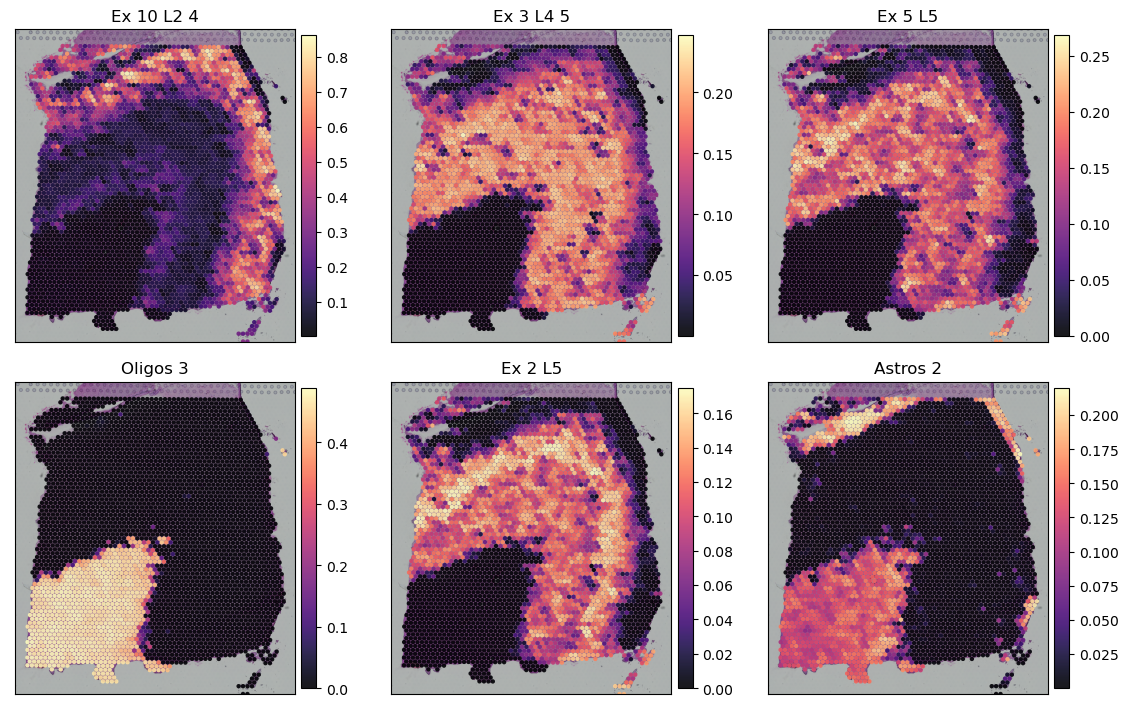

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(11.5, 7.2))
axes = axes.ravel()
for ax, key in zip(axes, top_celltypes):
    values = pd.to_numeric(adata.obs[key], errors="coerce")
    ax.imshow(he_img)
    sc_plot = ax.scatter(coords_he[:, 0], coords_he[:, 1], c=values, s=10, cmap="magma", linewidths=0, alpha=0.9)
    ax.set_title(key.replace("_", " "))
    ax.set_xlim(max(x_min - pad, 0), min(x_max + pad, he_img.shape[1]))
    ax.set_ylim(min(y_max + pad, he_img.shape[0]), max(y_min - pad, 0))
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(sc_plot, ax=ax, fraction=0.046, pad=0.02)
plt.tight_layout()
plt.show()


## Spatial A-to-I Editome

Load the A-to-I editing matrix, transfer spatial metadata, compute a global A-to-I score, inspect ADAR-family expression, and detect spatially variable A-to-I sites.


### load data

#### Paths and parameters

In [9]:
MAIN_SAMPLE_ID = "151673"
COMPARISON_SAMPLE_IDS = ["151671", "151507"]
SAMPLE_IDS = [MAIN_SAMPLE_ID] + COMPARISON_SAMPLE_IDS

sample_id = MAIN_SAMPLE_ID
PLOT_EXPORT_SCOPE = sample_id
base_dir = f"D:/data/SPARROW_data/DLPFC/{sample_id}"

sc_path = "D:/data/SPARROW_data/DLPFC/scRNA.h5ad"
h5_path = f"{base_dir}/filtered_feature_bc_matrix.h5"
tissue_position_path = f"{base_dir}/spatial/tissue_positions_list.csv"
label_path = f"{base_dir}/cluster_labels_{sample_id}.csv"
adata_ai_path = f"{base_dir}/adata_ai.h5ad"

# H&E image used as the background for all spatial plots.
he_image_path = f"D:/data/SPARROW_data/DLPFC/{sample_id}/spatial/tissue_hires_image.png"
spatial_scalefactors_path = f"D:/data/SPARROW_data/DLPFC/{sample_id}/spatial/scalefactors_json.json"
SPATIAL_SWAP_X_Y = sample_id in {"151673"}
SPATIAL_CROP = True
SPATIAL_CROP_PAD = 120
SPATIAL_COORDINATE_SCALE = None

# deconvolution file for the selected sample
deconv_path = f"{base_dir}/adata_obs_SPARROW.csv"

GROUP_KEY = "ground_truth"

ADAR_GENES = ("ADAR", "ADARB1", "ADARB2")
SPATIAL_COVARIATES = ("x_pixel", "y_pixel")

# Optional local annotation resources for mechanism overlap.
# External annotation resources; all coordinate-level files use GRCh38/hg38.
EXTERNAL_ANNOTATION_PATHS = {
    "miRBase": {"path": r"D:\data\SPARROW_data\Annotation\miRBase\hsa.gff3", "type": "gff3"},
    "miRGeneDB": {"path": r"D:\data\SPARROW_data\Annotation\miRGeneDB\hsa-all.bed", "type": "bed"},
    "RepeatMasker/Alu": {"path": r"D:\data\SPARROW_data\Annotation\RepeatMasker\rmsk.txt.gz", "type": "repeatmasker"},
    "REDIportal": {"path": r"D:\data\SPARROW_data\Annotation\REDIportal\TABLE1_hg38_v3.txt", "type": "rediportal"},
    "TargetScan gene information": {
        "path": r"D:\data\SPARROW_data\Annotation\TargetScan\Gene_info.txt.zip",
        "type": "gene",
        "gene_col": "Gene symbol",
        "name_col": "Gene description",
        "filters": {"Species ID": "9606"},
        "scope": "human_gene_reference",
    },
    "TargetScan miRNA families": {
        "path": r"D:\data\SPARROW_data\Annotation\TargetScan\miR_Family_Info.txt.zip",
        "type": "catalog",
        "scope": "human_miRNA_family_reference_catalog",
    },
    "TargetScan predictions": {
        "path": r"D:\data\SPARROW_data\Annotation\TargetScan\Summary_Counts.all_predictions.txt.zip",
        "type": "gene",
        "gene_col": "Gene Symbol",
        "name_col": "Representative miRNA",
        "filters": {"Species ID": "9606"},
        "scope": "human_gene_miRNA_prediction",
    },
    "RBP": {
        "path": r"D:\data\SPARROW_data\Annotation\RBP\ENCODE_eCLIP_GRCh38_bed",
        "type": "bed",
        "name_regex": r"_IDR(?:$|_)",
        "prefilter_files_by_first_name": True,
        "label_parser": "rbp",
        "deduplicate_labels_per_site": True,
        "scope": "ENCODE_eCLIP_IDR_peaks_deduplicated_by_RBP",
    },
}

print("Main sample:", MAIN_SAMPLE_ID)
print("Comparison samples:", COMPARISON_SAMPLE_IDS)
print("H&E image:", he_image_path)
print("swap_x_y for spatial plotting:", SPATIAL_SWAP_X_Y)
for _record_name in [
    "model_validation_records",
    "global_moran_records",
    "sv_top_site_records",
    "single_slice_sv_wm_binomial_records",
    "sv_annotation_records",
    "go_enrichment_records",
    "sv_gene_followup_records",
    "rbp_followup_records",
    "external_overlap_records",
    "external_overlap_summary_records",
    "mechanism_context_records",
]:
    if _record_name not in globals():
        globals()[_record_name] = []


Main sample: 151673
Comparison samples: ['151671', '151507']
H&E image: D:/data/SPARROW_data/DLPFC/151673/spatial/tissue_hires_image.png
swap_x_y for spatial plotting: True


#### Load spatial expression data and ground-truth labels

In [10]:
adata_sc = sc.read_h5ad(sc_path)

adata = sc.read_10x_h5(h5_path)
adata.var_names_make_unique()

tissue_positions = pd.read_csv(
    tissue_position_path,
    header=None,
)

tissue_positions.columns = [
    "barcode", "in_tissue", "x_array", "y_array", "x_pixel", "y_pixel"
]

tissue_positions = tissue_positions.set_index("barcode")

aligned_positions = tissue_positions.reindex(adata.obs_names)

adata.obs["in_tissue"] = aligned_positions["in_tissue"].values
adata.obs["x_array"] = aligned_positions["x_array"].values
adata.obs["y_array"] = aligned_positions["y_array"].values
adata.obs["x_pixel"] = aligned_positions["x_pixel"].values
adata.obs["y_pixel"] = aligned_positions["y_pixel"].values

if adata.obs[["x_pixel", "y_pixel"]].isnull().any().any():
    print("Warning: Some spots are missing coordinate info. Filled with 0.")

adata.obs[["x_pixel", "y_pixel"]] = adata.obs[["x_pixel", "y_pixel"]].fillna(0)

adata.obsm["spatial"] = adata.obs[["x_pixel", "y_pixel"]].values.astype(int)
adata.X = adata.X.astype(np.float32)

label_df = pd.read_csv(label_path)

label_df["barcode"] = label_df["key"].str.split("_", n=1).str[1]
label_df = label_df.set_index("barcode")

adata.obs[GROUP_KEY] = adata.obs_names.map(label_df[GROUP_KEY])
adata.obs[GROUP_KEY] = adata.obs[GROUP_KEY].replace(
    ["nan", "None", "NA", "null", ""],
    np.nan,
)

if os.path.exists(spatial_scalefactors_path):
    with open(spatial_scalefactors_path, "r") as f:
        spatial_scalefactors = json.load(f)
    SPATIAL_COORDINATE_SCALE = spatial_scalefactors.get("tissue_hires_scalef", 1.0)
else:
    spatial_scalefactors = {}
    SPATIAL_COORDINATE_SCALE = 1.0

print("H&E coordinate scale:", SPATIAL_COORDINATE_SCALE)

adata = atoi.set_spatial_background(
    adata,
    image_path=he_image_path,
    swap_x_y=SPATIAL_SWAP_X_Y,
    coordinate_scale=SPATIAL_COORDINATE_SCALE,
    crop=SPATIAL_CROP,
    crop_pad=SPATIAL_CROP_PAD,
    image_alpha=0.78,
)

print(adata)
display(adata.obs.head())
print("Ground truth counts:")
display(adata.obs[GROUP_KEY].value_counts(dropna=False))


H&E coordinate scale: 0.150015
AnnData object with n_obs × n_vars = 3639 × 33538
    obs: 'in_tissue', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'ground_truth'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial_background'
    obsm: 'spatial'


,in_tissue,x_array,y_array,x_pixel,y_pixel,ground_truth
AAACAAGTATCTCCCA-1,1,50,102,8468,9791,Layer_3
AAACAATCTACTAGCA-1,1,3,43,2807,5769,Layer_1
AAACACCAATAACTGC-1,1,59,19,9505,4068,WM
AAACAGAGCGACTCCT-1,1,14,94,4151,9271,Layer_3
AAACAGCTTTCAGAAG-1,1,43,9,7583,3393,Layer_5


Ground truth counts:


Layer_3    989
Layer_6    692
Layer_5    673
WM         513
Layer_1    273
Layer_2    253
Layer_4    218
NaN         28
Name: ground_truth, dtype: int64

#### Load A-to-I AnnData and transfer metadata

In [11]:
adata_ai = sc.read_h5ad(adata_ai_path)
atoi_before_filter_var = adata_ai.var.copy()
atoi_before_filter_sample_id = str(sample_id)
adata_ai = atoi.transfer_obs_metadata(
    source_adata=adata,
    target_adata=adata_ai,
    columns=("x_pixel", "y_pixel", "x_array", "y_array", "in_tissue", GROUP_KEY),
)

adata_ai = atoi.set_spatial_background(
    adata_ai,
    image_path=he_image_path,
    swap_x_y=SPATIAL_SWAP_X_Y,
    coordinate_scale=SPATIAL_COORDINATE_SCALE,
    crop=SPATIAL_CROP,
    crop_pad=SPATIAL_CROP_PAD,
    image_alpha=0.78,
)

print(adata_ai)
display(adata_ai.obs[[GROUP_KEY, "x_pixel", "y_pixel"]].head())
display(adata_ai.obs[GROUP_KEY].value_counts(dropna=False))


AnnData object with n_obs × n_vars = 3639 × 46103
    obs: 'x_pixel', 'y_pixel', 'x_array', 'y_array', 'in_tissue', 'ground_truth'
    var: 'chr', 'pos', 'Accession', 'Region', 'Position', 'Ref', 'Ed', 'Strand', 'db', 'type', 'dbsnp', 'repeat', 'Func.wgEncodeGencodeBasicV45', 'Gene.wgEncodeGencodeBasicV45', 'ExonicFunc.wgEncodeGencodeBasicV45', 'AAChange.wgEncodeGencodeBasicV45', 'Func.refGene', 'Gene.refGene', 'ExonicFunc.refGene', 'AAChange.refGene', 'Func.knownGene', 'Gene.knownGene', 'ExonicFunc.knownGene', 'AAChange.knownGene', 'phastConsElements100way', 'nSamples', 'nTissues', 'sTissue', 'sBody', 'nBodySites', 'PlotsBody', 'geneID', 'geneType', 'geneTag', 'uniprotID', 'rnacentral', 'nTCGASamples', 'nTCGAPrj', 'sTCGAprj', 'sTCGAdiseasetype', 'nTCGAdiseasetype', 'PlotsTCGA', 'PRIDE', 'REDInet_BS', 'REDInet_mean'
    uns: 'count_update_comparison', 'spatial_background'
    obsm: 'spatial'
    layers: 'A', 'G'


,ground_truth,x_pixel,y_pixel
ATAGGCGGCTATAGAA-1,Layer_6,7595,5046
GTAAGCGGGCAGTCAG-1,Layer_5,5214,7129
TTAAACAGAGTCCCGC-1,Layer_1,3518,4662
GGCGCTTCATTCCCTG-1,Layer_5,10489,7642
AACGCTGTTGCTGAAA-1,Layer_3,8943,9237


Layer_3    989
Layer_6    692
Layer_5    673
WM         513
Layer_1    273
Layer_2    253
Layer_4    218
NaN         28
Name: ground_truth, dtype: int64

### Global A-to-I

#### Reliable A-to-I site filtering

In [12]:
adata_ai, keep_mask = atoi.filter_atoi_sites(
    adata_ai,
    min_spot_cov=5,
    min_n_spots=5,
    min_site_ratio=0,
    max_site_ratio=0.5,
    min_site_ratio_sd=None,
    copy=True,
    verbose=True,
)

adata_ai = atoi.set_spatial_background(
    adata_ai,
    image_path=he_image_path,
    swap_x_y=SPATIAL_SWAP_X_Y,
    coordinate_scale=SPATIAL_COORDINATE_SCALE,
    crop=SPATIAL_CROP,
    crop_pad=SPATIAL_CROP_PAD,
    image_alpha=0.78,
)

filtered_atoi_sites = adata_ai.var.copy()
display(filtered_atoi_sites.head())
display(filtered_atoi_sites[["total_A", "total_G", "total_cov", "site_G_ratio", "site_G_ratio_sd", "n_spots_cov_gt5"]].describe())


Before: 46103
After : 6243
Removed: 39860

Filtering criteria:
  site_G_ratio is not NaN
  site_G_ratio > 0
  site_G_ratio < 0.5
  n_spots_cov_gt5 >= 5


,chr,pos,Accession,Region,Position,Ref,Ed,Strand,db,type,...,PlotsTCGA,PRIDE,REDInet_BS,REDInet_mean,total_A,total_G,total_cov,site_G_ratio,site_G_ratio_sd,n_spots_cov_gt5
10_100232882,10,100232882,EDHSAAHT9753,chr10,100232882,T,C,-,A,ALU,...,"0.03,0.02,0.03,0.01,0.04,0.01-0.03,0.02,0.03,0...",-,"1.0,-1,-1,1.0,-1,1.0,-1,-1,-1,1.0,1.0,-1,-1,-1...",1.000000,162,33,195,0.169231,0.249444,15
10_100232885,10,100232885,EDHSAAHT9754,chr10,100232885,T,C,-,A,ALU,...,"0.04,0.03,0.06,0.02,0.11,0.01-0.05,0.04,0.06,0...",-,"1.0,-1,-1,1.0,-1,1.0,-1,-1,-1,1.0,1.0,-1,-1,-1...",1.000000,158,56,214,0.261682,0.339935,15
10_100232888,10,100232888,EDHSAAHT9756,chr10,100232888,T,C,-,A,ALU,...,"0.03,0.02,0.03,0.02,0.04,0.01-0.03,0.02,0.03,0...",-,"1.0,-1,-1,1.0,-1,1.0,-1,-1,-1,1.0,1.0,-1,-1,-1...",1.000000,185,33,218,0.151376,0.242061,16
10_100232926,10,100232926,EDHSAAHT9773,chr10,100232926,T,C,-,A,ALU,...,"0.09,0.07,0.12,0.04,0.19,0.02-0.11,0.10,0.15,0...",-,"0.9999999966216216,0.9999626495852536,0.999962...",0.999450,174,170,344,0.494186,0.487498,18
10_100232927,10,100232927,EDHSAAHT9774,chr10,100232927,T,C,-,A,ALU,...,"0.04,0.03,0.05,0.02,0.09,0.01-0.05,0.04,0.06,0...",-,"0.9999999996561604,1.0,1.0,1.0,1.0,1.0,1.0,1.0...",0.999896,317,28,345,0.081159,0.229061,18


,total_A,total_G,total_cov,site_G_ratio,site_G_ratio_sd,n_spots_cov_gt5
count,6243.000000,6243.000000,6243.000000,6243.000000,6243.000000,6243.00000
mean,1435.165145,18.690854,1453.855999,0.067904,0.153555,67.92888
std,5693.876705,63.678232,5695.613797,0.101027,0.173610,191.28869
min,20.000000,1.000000,29.000000,0.000031,0.000000,5.00000
25%,115.000000,2.000000,129.000000,0.003396,0.001938,7.00000
50%,244.000000,5.000000,260.000000,0.018868,0.032015,14.00000
75%,824.000000,17.000000,849.500000,0.091788,0.330719,39.00000
max,161112.000000,2730.000000,161139.000000,0.496894,0.500000,3494.00000


#### Repeat composition and Alu genomic regions: before filtering vs global


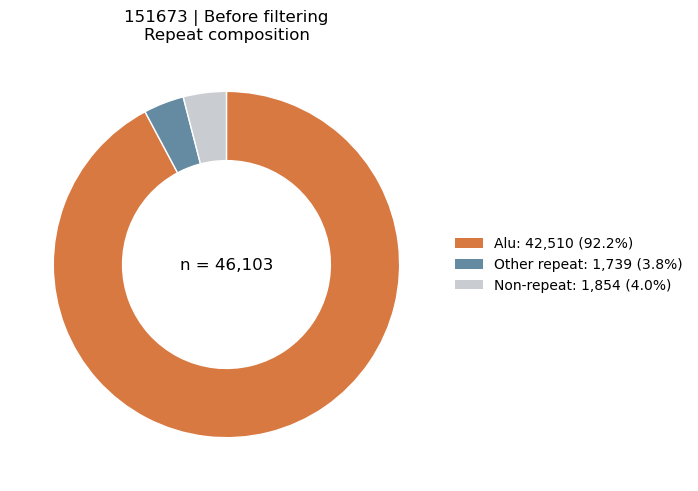

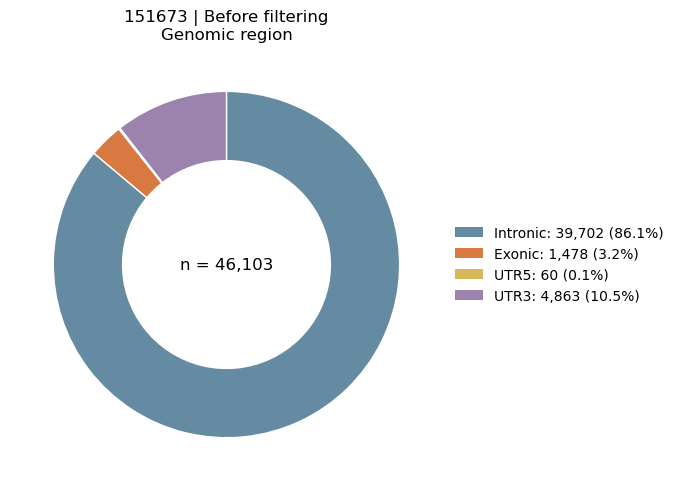

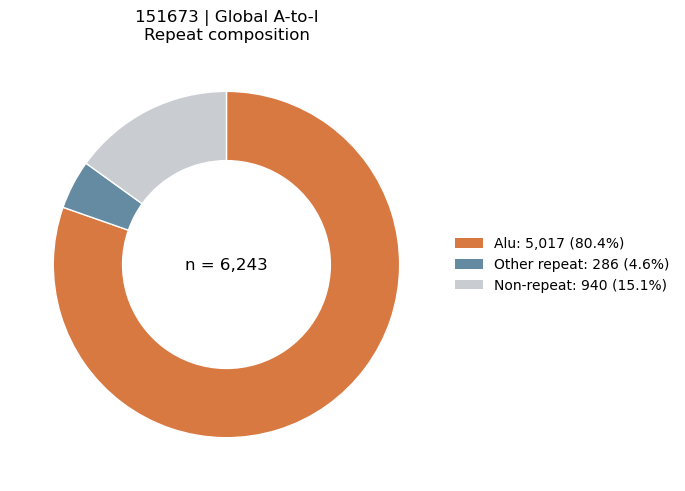

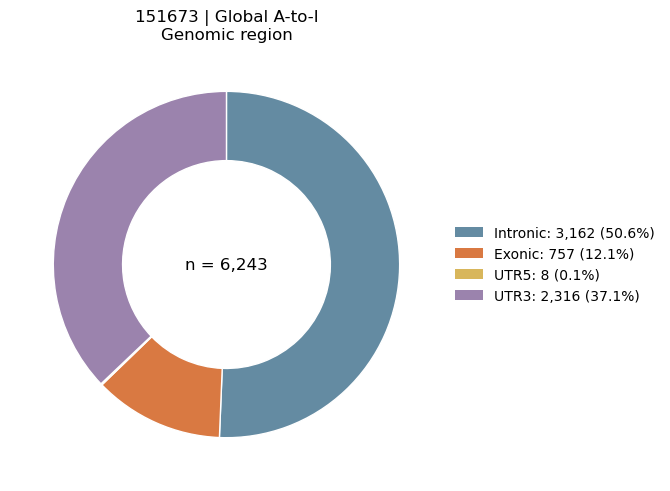

,sample_id,stage,panel,category,n,denominator,percent
0,151673,before_filter,repeat,Alu,42510,46103,92.206581
1,151673,before_filter,repeat,Other repeat,1739,46103,3.771989
2,151673,before_filter,repeat,Non-repeat,1854,46103,4.021430
3,151673,before_filter,region,Intronic,39702,46103,86.115871
4,151673,before_filter,region,Exonic,1478,46103,3.205865
5,151673,before_filter,region,UTR5,60,46103,0.130143
6,151673,before_filter,region,UTR3,4863,46103,10.548121
7,151673,global,repeat,Alu,5017,6243,80.362005
8,151673,global,repeat,Other repeat,286,6243,4.581131
9,151673,global,repeat,Non-repeat,940,6243,15.056864


In [13]:
if atoi_before_filter_sample_id != str(sample_id):
    raise RuntimeError("Reload this slice before plotting its pre-filter annotations.")
annotation_distribution_summary = atoi.plot_atoi_annotation_distributions(
    atoi_before_filter_var, adata_ai.var, sample_id,
    save=False,
)
display(annotation_distribution_summary)


#### Compute global A-to-I score

In [14]:
global_score = atoi.compute_multisite_atoi_score(
    adata_ai,
    sites=None,
    score_name="global_atoi_score",
    min_cov=5,
    top_n=None,
    weight_col=None,
    require_sv=False,
    zscore_sites=False,
)

global_ratio = atoi.compute_global_atoi_ratio(
    adata_ai,
    ratio_key="global_atoi_ratio",
    coverage_key="global_atoi_cov",
    min_total_cov=10,
)

display(
    adata_ai.obs[
        [
            "global_atoi_score",
            "global_atoi_score_n_sites",
            "global_atoi_score_mean_cov",
            "global_atoi_ratio",
            "global_atoi_cov",
        ]
    ].describe()
)


,global_atoi_score,global_atoi_score_n_sites,global_atoi_score_mean_cov,global_atoi_ratio,global_atoi_cov
count,3612.000000,3639.000000,3612.000000,3638.000000,3639.000000
mean,0.016288,116.537510,14.698864,0.012218,2494.208024
std,0.039682,100.961225,4.790824,0.017803,2169.256274
min,0.000000,0.000000,5.000000,0.000000,8.000000
25%,0.000000,41.000000,11.329970,0.002365,995.500000
50%,0.004650,89.000000,14.130286,0.005965,1863.000000
75%,0.020581,164.000000,17.270089,0.014724,3305.000000
max,1.000000,771.000000,47.254237,0.287841,19362.000000


#### Global A-to-I spatial pattern

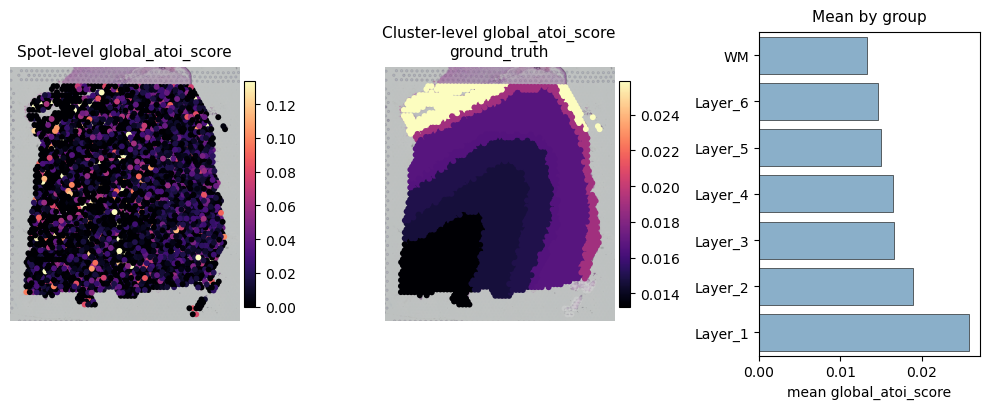

In [15]:
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"

fig, axes, global_summary = atoi.plot_cluster_level_obs_value(
    adata_ai,
    value_key="global_atoi_score",
    group_key=GROUP_KEY,
    cmap="magma",
)

plt.show()


### ADAR-family

#### ADAR-family spatial patterns

ADAR-family expression is transferred as `log1p(CP10K)` so that spot-level library size does not directly drive the cluster summaries.

Added ADAR expression columns: ['expr_ADAR', 'expr_ADARB1', 'expr_ADARB2']
Added compact ADAR-family module: expr_ADAR_family_score


,expr_ADAR,expr_ADARB1,expr_ADARB2,expr_ADAR_family_score
count,3639.000000,3639.000000,3639.000000,3.639000e+03
mean,0.563730,0.201663,0.094915,-4.198040e-17
std,0.704296,0.473206,0.347547,5.766933e-01
min,0.000000,0.000000,0.000000,-4.998932e-01
25%,0.000000,0.000000,0.000000,-4.998932e-01
50%,0.000000,0.000000,0.000000,-5.709348e-02
75%,1.198807,0.000000,0.000000,3.209634e-01
max,2.911878,2.895043,3.126168,3.438869e+00


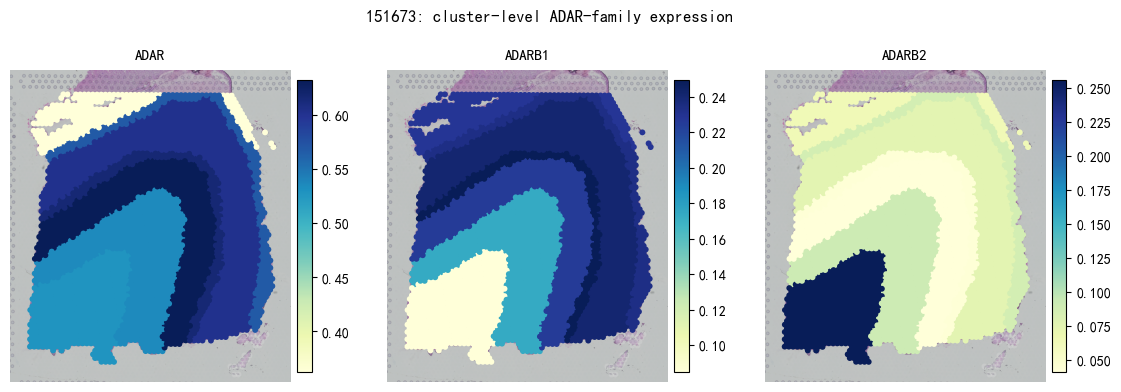

,group,mean,value_key
0,Layer_1,0.362173,expr_ADAR
1,Layer_2,0.567712,expr_ADAR
2,Layer_3,0.602041,expr_ADAR
3,Layer_4,0.616052,expr_ADAR
4,Layer_5,0.632245,expr_ADAR
5,Layer_6,0.535619,expr_ADAR
6,WM,0.528086,expr_ADAR
7,Layer_1,0.228021,expr_ADARB1
8,Layer_2,0.233758,expr_ADARB1
9,Layer_3,0.241005,expr_ADARB1


In [16]:
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"


mpl.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei", "Microsoft YaHei"]
mpl.rcParams["axes.unicode_minus"] = False

added_adar_cols = atoi.add_gene_expression_to_obs(
    adata_expr=adata,
    target_adata=adata_ai,
    genes=ADAR_GENES,
    prefix="expr_",
    layer=None,
    normalize_total=True,
    target_sum=1e4,
    log1p=True,
)

print("Added ADAR expression columns:", added_adar_cols)

adar_family_score = atoi.add_obs_zmean_score(
    adata_ai,
    cols=added_adar_cols,
    score_name="expr_ADAR_family_score",
    min_nonmissing=1,
)

print("Added compact ADAR-family module: expr_ADAR_family_score")
display(adata_ai.obs[added_adar_cols + ["expr_ADAR_family_score"]].describe())

fig, axes, adar_cluster_summary = atoi.plot_cluster_level_obs_panel(
    adata_ai,
    value_keys=added_adar_cols,
    group_key=GROUP_KEY,
    cmap="YlGnBu",
    figsize=(11.4, 3.8),
    title=f"{sample_id}: cluster-level ADAR-family expression",
)

plt.show()
plt.close(fig)

display(adar_cluster_summary)

#### ADAR-family cluster-level spatial correlation table


Cluster-level mean ADAR-family expression:


,expr_ADAR,expr_ADARB1,expr_ADARB2
ground_truth,,,
Layer_1,0.362173,0.228021,0.063806
Layer_2,0.567712,0.233758,0.086897
Layer_3,0.602041,0.241005,0.075035
Layer_4,0.616052,0.249431,0.042758
Layer_5,0.632245,0.225020,0.040718
Layer_6,0.535619,0.174111,0.090557
WM,0.528086,0.084712,0.255769


Cluster-level Spearman correlation among ADAR-family genes:


,expr_ADAR,expr_ADARB1,expr_ADARB2
expr_ADAR,1.000000,0.464286,-0.642857
expr_ADARB1,0.464286,1.000000,-0.535714
expr_ADARB2,-0.642857,-0.535714,1.000000


Cluster-level Spearman p values:


,expr_ADAR,expr_ADARB1,expr_ADARB2
expr_ADAR,0.000000,0.293934,0.119392
expr_ADARB1,0.293934,0.000000,0.215217
expr_ADARB2,0.119392,0.215217,0.000000


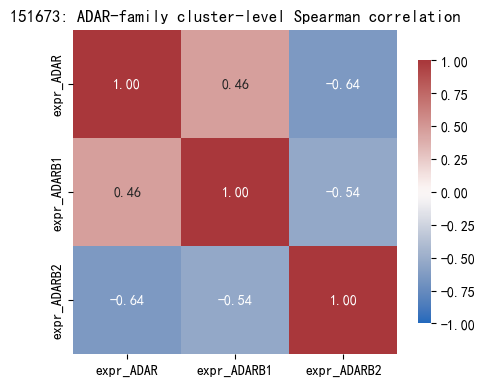

In [17]:
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"


mpl.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei", "Microsoft YaHei"]
mpl.rcParams["axes.unicode_minus"] = False

adar_corr = atoi.analyze_adar_spatial_correlation(
    adata_ai,
    adar_cols=added_adar_cols,
    group_key=GROUP_KEY,
    method="spearman",
    cluster_agg="mean",
)

print("Cluster-level mean ADAR-family expression:")
display(adar_corr["cluster_mean"])

print("Cluster-level Spearman correlation among ADAR-family genes:")
display(adar_corr["cluster_corr"])

print("Cluster-level Spearman p values:")
display(adar_corr["cluster_p"])

fig, ax = atoi.plot_cluster_adar_correlation_heatmap(
    adar_corr,
    title=f"{sample_id}: ADAR-family cluster-level Spearman correlation",
)


plt.show()
plt.close(fig)

### residual analysis

#### Load deconvolution and collapse to major cell types

In [18]:
df_deconv_raw = pd.read_csv(deconv_path, index_col=0)

print("Raw deconvolution shape:", df_deconv_raw.shape)
display(df_deconv_raw.head())


metadata_cols = {
    "in_tissue", "x_array", "y_array", "x_pixel", "y_pixel",
    "array_row", "array_col", "celltype_sum",
    "leiden", "seurat_clusters", "ground_truth",
    "barcode", "key", "sample", "sample_id",
    "n_counts", "total_counts", "n_genes", "n_genes_by_counts",
    "pct_counts_mt", "batch",
}

raw_celltype_cols = []

for col in df_deconv_raw.columns:
    if col in metadata_cols:
        continue

    if not pd.api.types.is_numeric_dtype(df_deconv_raw[col]):
        continue

    x = pd.to_numeric(df_deconv_raw[col], errors="coerce")

    if x.dropna().empty:
        continue

    if x.std(skipna=True) <= 1e-10:
        continue

    raw_celltype_cols.append(col)

print("Raw candidate cell-type columns:", len(raw_celltype_cols))
print(raw_celltype_cols)


Raw deconvolution shape: (3639, 38)


,in_tissue,x_array,y_array,x_pixel,y_pixel,Astros_1,Astros_2,Astros_3,Endo,Ex_10_L2_4,...,Mix_1,Mix_2,Mix_3,Mix_4,Mix_5,OPCs_1,OPCs_2,Oligos_1,Oligos_2,Oligos_3
AAACAAGTATCTCCCA-1,1,50,102,8468,9791,0.000000,0.001096,0.000000,0.000760,0.626498,...,0.001519,0.016975,0.005916,0.001773,0.011392,0.001434,0.000000,0.000000,0.000000,0.000337
AAACAATCTACTAGCA-1,1,3,43,2807,5769,0.019909,0.204838,0.086690,0.021917,0.121360,...,0.007845,0.072787,0.005796,0.006991,0.033696,0.018482,0.001927,0.000000,0.000000,0.002602
AAACACCAATAACTGC-1,1,59,19,9505,4068,0.011671,0.118165,0.079601,0.013725,0.017102,...,0.000237,0.005174,0.000394,0.010141,0.011995,0.094006,0.038680,0.028036,0.004013,0.481602
AAACAGAGCGACTCCT-1,1,14,94,4151,9271,0.000000,0.003293,0.000000,0.001099,0.609061,...,0.001519,0.018836,0.004819,0.002192,0.016381,0.002195,0.000000,0.000000,0.000000,0.000000
AAACAGCTTTCAGAAG-1,1,43,9,7583,3393,0.000000,0.002024,0.000000,0.000507,0.094812,...,0.008115,0.067895,0.018360,0.006246,0.021279,0.000928,0.000000,0.000000,0.000000,0.000675


Raw candidate cell-type columns: 33
['Astros_1', 'Astros_2', 'Astros_3', 'Endo', 'Ex_10_L2_4', 'Ex_1_L5_6', 'Ex_2_L5', 'Ex_3_L4_5', 'Ex_4_L_6', 'Ex_5_L5', 'Ex_6_L4_6', 'Ex_7_L4_6', 'Ex_8_L5_6', 'Ex_9_L5_6', 'Inhib_1', 'Inhib_2_VIP', 'Inhib_3_SST', 'Inhib_4_SST', 'Inhib_5', 'Inhib_6_SST', 'Inhib_7_PVALB', 'Inhib_8_PVALB', 'Micro/Macro', 'Mix_1', 'Mix_2', 'Mix_3', 'Mix_4', 'Mix_5', 'OPCs_1', 'OPCs_2', 'Oligos_1', 'Oligos_2', 'Oligos_3']


##### combine the cell type

Cell type mapping:


,raw_celltype,merged_celltype
0,Astros_1,Astros
1,Astros_2,Astros
2,Astros_3,Astros
3,Endo,Endo
4,Ex_10_L2_4,Ex_L2_4
5,Ex_1_L5_6,Ex_L5_6
6,Ex_2_L5,Ex_L5
7,Ex_3_L4_5,Ex_L4_5
8,Ex_4_L_6,Ex_L6
9,Ex_5_L5,Ex_L5


Merged groups:


Inhib          8
Mix            5
Astros         3
Ex_L5_6        3
Oligos         3
Ex_L5          2
Ex_L4_6        2
OPCs           2
Endo           1
Ex_L2_4        1
Ex_L4_5        1
Ex_L6          1
Micro/Macro    1
Name: merged_celltype, dtype: int64

Merged spot-level deconvolution shape: (3639, 17)
Merged cell type columns:
['Astros', 'Endo', 'Ex_L2_4', 'Ex_L4_5', 'Ex_L4_6', 'Ex_L5', 'Ex_L5_6', 'Ex_L6', 'Inhib', 'Micro/Macro', 'Mix', 'OPCs', 'Oligos']
Cell-type composition modules:


...

,Astros,Endo,Ex_L2_4,Ex_L4_5,Ex_L4_6,Ex_L5,Ex_L5_6,Ex_L6,Inhib,Micro/Macro,Mix,OPCs,Oligos,celltype_glial_module,celltype_excitatory_module,celltype_inhibitory_module,celltype_vascular_module
AAACAAGTATCTCCCA-1,0.001096,0.000760,0.626498,0.139942,0.008263,0.154829,0.003627,0.002699,0.017792,0.005150,0.037574,0.001434,0.000337,0.008017,0.935858,0.017792,0.000760
AAACAATCTACTAGCA-1,0.311436,0.021917,0.121360,0.014005,0.003021,0.023737,0.002100,0.002265,0.304313,0.045721,0.127115,0.020409,0.002602,0.380167,0.166488,0.304313,0.021917
AAACACCAATAACTGC-1,0.209437,0.013725,0.017102,0.000241,0.003122,0.000078,0.002546,0.000957,0.033842,0.044674,0.027941,0.132686,0.513650,0.900447,0.024045,0.033842,0.013725
AAACAGAGCGACTCCT-1,0.003293,0.001099,0.609061,0.132095,0.014513,0.113736,0.002530,0.002279,0.069961,0.005490,0.043748,0.002195,0.000000,0.010978,0.874213,0.069961,0.001099
AAACAGCTTTCAGAAG-1,0.002024,0.000507,0.094812,0.169200,0.096995,0.291643,0.085725,0.009623,0.120398,0.005575,0.121896,0.000928,0.000675,0.009201,0.747998,0.120398,0.000507


,Astros,Endo,Ex_L2_4,Ex_L4_5,Ex_L4_6,Ex_L5,Ex_L5_6,Ex_L6,Inhib,Micro/Macro,Mix,OPCs,Oligos,celltype_glial_module,celltype_excitatory_module,celltype_inhibitory_module,celltype_vascular_module
count,3639.000000,3639.000000,3639.000000,3639.000000,3639.000000,3639.000000,3639.000000,3639.000000,3639.000000,3639.000000,3639.000000,3639.000000,3639.000000,3639.000000,3639.000000,3639.000000,3639.000000
mean,0.072019,0.004151,0.206251,0.110968,0.054588,0.173299,0.030175,0.002792,0.121915,0.014379,0.073034,0.029816,0.106615,0.222829,0.578072,0.121915,0.004151
std,0.108008,0.005926,0.212261,0.080021,0.079361,0.140521,0.037626,0.003362,0.162867,0.015778,0.037516,0.049778,0.200016,0.354514,0.343253,0.162867,0.005926
min,0.000084,0.000000,0.004052,0.000082,0.000254,0.000000,0.000000,0.000000,0.000253,0.001603,0.011900,0.000000,0.000000,0.002785,0.006540,0.000253,0.000000
25%,0.001350,0.000253,0.046830,0.020349,0.002701,0.008933,0.002483,0.000928,0.015085,0.004137,0.040411,0.000842,0.000084,0.006923,0.240390,0.015085,0.000253
50%,0.002701,0.000675,0.112653,0.128471,0.011138,0.193349,0.008594,0.001518,0.040728,0.005402,0.067900,0.001603,0.000421,0.010467,0.724238,0.040728,0.000675
75%,0.186356,0.008282,0.312862,0.187871,0.081312,0.297676,0.055632,0.002953,0.172495,0.021588,0.098234,0.031374,0.004556,0.346938,0.867218,0.172495,0.008282
max,0.334541,0.027974,0.861294,0.246866,0.348410,0.442618,0.148150,0.027173,0.890661,0.068703,0.210047,0.151948,0.520702,0.945568,0.978650,0.890661,0.027974


Cluster-level deconvolution shape: (7, 17)


,n_spots
Layer_1,273
Layer_2,253
Layer_3,989
Layer_4,218
Layer_5,673
Layer_6,692
WM,513


,Astros,Endo,Ex_L2_4,Ex_L4_5,Ex_L4_6,Ex_L5,Ex_L5_6,Ex_L6,Inhib,Micro/Macro,Mix,OPCs,Oligos,celltype_glial_module,celltype_excitatory_module,celltype_inhibitory_module,celltype_vascular_module
Layer_1,0.201656,0.011727,0.273307,0.049260,0.005680,0.078354,0.003805,0.003811,0.223922,0.022967,0.086309,0.032544,0.006658,0.263825,0.414217,0.223922,0.011727
Layer_2,0.045357,0.002183,0.484195,0.053819,0.002283,0.045302,0.001801,0.002319,0.294941,0.007880,0.046988,0.012464,0.000469,0.066171,0.589718,0.294941,0.002183
Layer_3,0.003944,0.000826,0.392178,0.140284,0.013355,0.223320,0.008167,0.001816,0.139591,0.005061,0.069764,0.001610,0.000084,0.010699,0.779120,0.139591,0.000826
Layer_4,0.001651,0.000494,0.105081,0.165923,0.056534,0.316035,0.028239,0.000963,0.219267,0.004958,0.099809,0.000817,0.000229,0.007654,0.672775,0.219267,0.000494
Layer_5,0.002498,0.000410,0.082831,0.178542,0.177428,0.264984,0.081233,0.001937,0.120178,0.004536,0.082868,0.001098,0.001456,0.009589,0.786955,0.120178,0.000410
Layer_6,0.097815,0.005332,0.105434,0.111506,0.071778,0.175214,0.054410,0.006680,0.037826,0.017342,0.093938,0.038769,0.183958,0.337883,0.525020,0.037826,0.005332
WM,0.235885,0.012425,0.013610,0.000336,0.002701,0.000112,0.002593,0.000978,0.024572,0.044265,0.029735,0.130607,0.502181,0.912938,0.020330,0.024572,0.012425


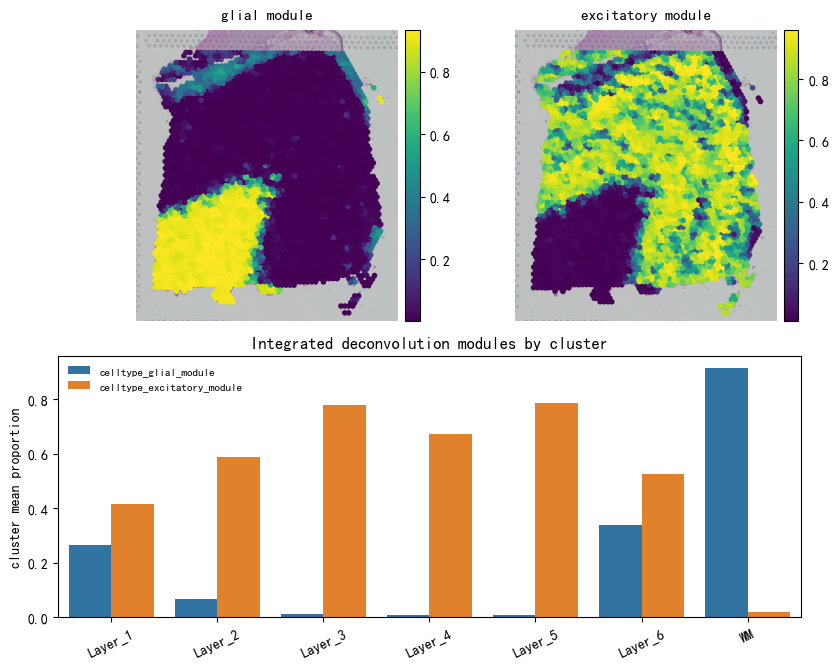

,celltype_glial_module,celltype_excitatory_module
ground_truth,,
Layer_1,0.263825,0.414217
Layer_2,0.066171,0.589718
Layer_3,0.010699,0.779120
Layer_4,0.007654,0.672775
Layer_5,0.009589,0.786955
Layer_6,0.337883,0.525020
WM,0.912938,0.020330


In [19]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt


mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"


mpl.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei", "Microsoft YaHei"]
mpl.rcParams["axes.unicode_minus"] = False


celltype_mapping = pd.DataFrame({
    "raw_celltype": raw_celltype_cols,
    "merged_celltype": [atoi.parse_dlpfc_celltype_group(c) for c in raw_celltype_cols],
})

print("Cell type mapping:")
display(celltype_mapping)

print("Merged groups:")
display(celltype_mapping["merged_celltype"].value_counts())


df_deconv = pd.DataFrame(index=df_deconv_raw.index)

for merged_name, sub in celltype_mapping.groupby("merged_celltype"):
    cols = sub["raw_celltype"].tolist()
    df_deconv[merged_name] = df_deconv_raw[cols].sum(axis=1)


df_deconv_export = df_deconv.copy()
export_celltype_cols = df_deconv_export.columns.tolist()
df_deconv_export, export_module_cols, _ = atoi.add_celltype_composition_modules(
    df_deconv_export,
    prefix="celltype",
    normalize_modules=False,
)
export_cluster_cols = export_celltype_cols + export_module_cols

row_sum = df_deconv.sum(axis=1).replace(0, np.nan)
df_deconv = df_deconv.div(row_sum, axis=0)

celltype_cols = df_deconv.columns.tolist()

df_deconv, celltype_module_cols, celltype_module_members = atoi.add_celltype_composition_modules(
    df_deconv,
    prefix="celltype",
    normalize_modules=False,
)


preferred_celltype_modules = ["celltype_glial_module", "celltype_excitatory_module"]
celltype_model_cols = [c for c in preferred_celltype_modules if c in df_deconv.columns]
if len(celltype_model_cols) < 1:
    fallback_modules = [c for c in celltype_module_cols if c in df_deconv.columns]
    celltype_model_cols = fallback_modules[:2]

cluster_deconv_cols = celltype_cols + celltype_module_cols

print("Merged spot-level deconvolution shape:", df_deconv.shape)
print("Merged cell type columns:")
print(celltype_cols)
print("Cell-type composition modules:")
display(celltype_module_members)
print("Cell-type module terms used in the main model:", celltype_model_cols)

display(df_deconv.head())
display(df_deconv[cluster_deconv_cols].describe())

cluster_deconv, df_deconv_cluster_spot, deconv_group_counts = atoi.collapse_deconvolution_to_clusters(
    adata_ai,
    df_deconv=df_deconv,
    celltype_cols=cluster_deconv_cols,
    group_key=GROUP_KEY,
    aggfunc="mean",
    normalize=False,
    min_spots_per_group=2,
)

print("Cluster-level deconvolution shape:", cluster_deconv.shape)
display(deconv_group_counts.to_frame("n_spots"))
display(cluster_deconv)


cluster_deconv_export, _, _ = atoi.collapse_deconvolution_to_clusters(
    adata_ai,
    df_deconv=df_deconv_export,
    celltype_cols=export_cluster_cols,
    group_key=GROUP_KEY,
    aggfunc="mean",
    normalize=False,
    min_spots_per_group=2,
)
cluster_deconv_by_slice = globals().get("cluster_deconv_by_slice", {})
cluster_deconv_by_slice[str(sample_id)] = cluster_deconv_export.copy()

fig, axes, celltype_module_summary = atoi.plot_celltype_module_deconvolution_summary(
    adata_ai,
    df_deconv=df_deconv,
    module_cols=celltype_model_cols,
    group_key=GROUP_KEY,
    cluster_agg="mean",
    cmap="viridis",
    figsize=(8.5, 6.8),
)


plt.show()
plt.close(fig)

display(celltype_module_summary)

#### Cluster-level cell-type composition and A-to-I association

In [20]:

celltype_assoc = atoi.analyze_score_vs_celltypes(
    adata_ai,
    df_deconv=df_deconv,
    score_key="global_atoi_score",
    celltype_cols=celltype_cols,
    covariates=(),
    min_complete=3,
    level="cluster",
    group_key=GROUP_KEY,
    cluster_agg="mean",
    store_key="cluster_global_atoi_vs_celltypes",
)

print("Cluster-level one-celltype associations without spatial covariates.")
display(celltype_assoc)


Cluster-level one-celltype associations without spatial covariates.


,celltype,level,group_key,n_clusters,spearman_rho,spearman_p,adjusted_beta,adjusted_p,adjusted_r2,n_spots,spearman_fdr,adjusted_fdr
0,Inhib,cluster,ground_truth,7,0.928571,0.002519,0.672837,0.097650,0.452709,NaN,0.032753,0.740072
1,Ex_L2_4,cluster,ground_truth,7,0.785714,0.036238,0.520905,0.230605,0.271343,NaN,0.235550,0.740072
2,Oligos,cluster,ground_truth,7,-0.535714,0.215217,-0.508222,0.244178,0.258290,NaN,0.932609,0.740072
3,Astros,cluster,ground_truth,7,-0.142857,0.759945,0.241202,0.602330,0.058178,NaN,0.939408,0.740072
4,Endo,cluster,ground_truth,7,-0.107143,0.819151,0.292983,0.523686,0.085839,NaN,0.939408,0.740072
5,Ex_L4_5,cluster,ground_truth,7,-0.035714,0.939408,-0.237986,0.607325,0.056637,NaN,0.939408,0.740072
6,Ex_L4_6,cluster,ground_truth,7,-0.357143,0.431611,-0.377334,0.404030,0.142381,NaN,0.939408,0.740072
7,Ex_L5,cluster,ground_truth,7,0.035714,0.939408,-0.231542,0.617374,0.053612,NaN,0.939408,0.740072
8,Ex_L5_6,cluster,ground_truth,7,-0.357143,0.431611,-0.423602,0.343615,0.179439,NaN,0.939408,0.740072
9,Mix,cluster,ground_truth,7,0.107143,0.819151,0.225897,0.626215,0.051029,NaN,0.939408,0.740072


##### Bivariate: global A-to-I vs top descriptive cell type

Top descriptive cell type for co-localization: Inhib


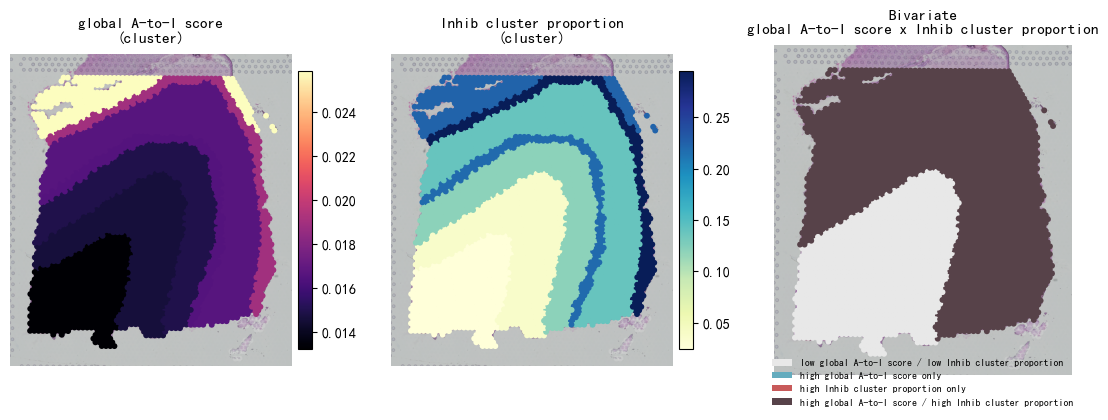

In [21]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt


mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"


mpl.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei", "Microsoft YaHei"]
mpl.rcParams["axes.unicode_minus"] = False


if not celltype_assoc.empty:

    positive = celltype_assoc[celltype_assoc["adjusted_beta"] > 0].copy()

    if not positive.empty:
        top_ct = positive.sort_values("spearman_p").iloc[0]["celltype"]
    else:
        top_ct = celltype_assoc.sort_values("spearman_p").iloc[0]["celltype"]

    print("Top descriptive cell type for co-localization:", top_ct)

    common = adata_ai.obs_names.intersection(df_deconv.index)

    top_ct_values = pd.Series(np.nan, index=adata_ai.obs_names, dtype=float)
    top_ct_values.loc[common] = df_deconv_cluster_spot.loc[common, top_ct].astype(float)

    fig, axes = atoi.plot_bivariate_colocalization(
        adata_ai,
        x_values=adata_ai.obs["global_atoi_score"].values,
        y_values=top_ct_values.values,
        x_name="global A-to-I score",
        y_name=f"{top_ct} cluster proportion",
        q=0.5,
        mode="cluster",
        group_key=GROUP_KEY,
        show_legend=True,
    )


    plt.show()
    plt.close(fig)

else:
    print("Skip global A-to-I vs top cell type co-localization.")

In [22]:

celltype_model_cols = [c for c in celltype_model_cols if c in df_deconv.columns]

if not celltype_model_cols:
    raise ValueError("No cell-type module model columns are available.")

print("Fixed cell-type composition module terms used in residual model:", celltype_model_cols)

residual_celltype, fit_celltype, params_celltype, summary_celltype = atoi.fit_adjustment_model(
    adata_ai,
    score_key="global_atoi_score",
    predictors=celltype_model_cols,
    df_extra=df_deconv,
    covariates=(),
    residual_key="global_atoi_residual_celltype",
    min_complete=3,
    drop_reference=None,
    level="cluster",
    group_key=GROUP_KEY,
    cluster_agg="mean",
    store_key="cluster_celltype_only_global_atoi_model",
)

summary_celltype["model_formula"] = "global_atoi_score ~ " + " + ".join(celltype_model_cols)
summary_celltype["celltype_selection_rule"] = "fixed_biology_informed_modules"
summary_celltype["celltype_model_cols"] = celltype_model_cols

print("Cluster-level cell-type-module-only model summary:")
display(pd.DataFrame([summary_celltype]))

print("Cluster-level cell-type-module-only model coefficients:")
display(params_celltype)


Fixed cell-type composition module terms used in residual model: ['celltype_glial_module', 'celltype_excitatory_module']
Cluster-level cell-type-module-only model summary:


,level,group_key,cluster_agg,n_spots,n_clusters,r2,adj_r2,residual_key,predictors,drop_reference,dropped_zero_var,condition_number,model_formula,celltype_selection_rule,celltype_model_cols
0,cluster,ground_truth,mean,NaN,7,0.630417,0.445626,global_atoi_residual_celltype,"[celltype_glial_module, celltype_excitatory_mo...",None,[],7.049773,global_atoi_score ~ celltype_glial_module + ce...,fixed_biology_informed_modules,"[celltype_glial_module, celltype_excitatory_mo..."


Cluster-level cell-type-module-only model coefficients:


,coef,pval,term,padj
0,0.017259,0.000130,const,0.000390
1,-0.012016,0.059554,celltype_glial_module,0.069421
2,-0.011352,0.069421,celltype_excitatory_module,0.069421


#### Core joint model

Use fixed biology-informed cell-type composition modules, then add the compact ADAR-family module. This avoids sample-adaptive top-celltype selection and keeps the cluster-level model descriptive and comparable across samples: `global A-to-I ~ glial/excitatory modules` versus `global A-to-I ~ glial/excitatory modules + ADAR_family_score`.


In [23]:

joint_celltype_cols = list(celltype_model_cols)
joint_adar_cols = ["expr_ADAR_family_score"]
joint_model_label = "Cell-type modules + ADAR-family score"

print("Joint model cell-type module terms:", joint_celltype_cols)
print("Joint model ADAR terms:", joint_adar_cols)

residual_joint, fit_joint, joint_params, joint_summary = atoi.fit_joint_atoi_model(
    adata_ai,
    df_deconv=df_deconv,
    score_key="global_atoi_score",
    celltype_cols=joint_celltype_cols,
    adar_cols=joint_adar_cols,
    covariates=(),
    residual_key="global_atoi_residual_celltype_adar",
    drop_reference=None,
    min_complete=3,
    level="cluster",
    group_key=GROUP_KEY,
    cluster_agg="mean",
    store_key="cluster_joint_global_atoi_model",
)

joint_summary["joint_adar_cols"] = joint_adar_cols
joint_summary["joint_model_label"] = joint_model_label
joint_summary["model_formula"] = "global_atoi_score ~ " + " + ".join(joint_celltype_cols + joint_adar_cols)
joint_summary["celltype_selection_rule"] = summary_celltype.get("celltype_selection_rule", "")
joint_summary["celltype_model_cols"] = joint_celltype_cols

partial_r2_adar = (
    (joint_summary.get("r2", np.nan) - summary_celltype.get("r2", np.nan))
    / (1 - summary_celltype.get("r2", np.nan))
    if pd.notna(summary_celltype.get("r2", np.nan)) and summary_celltype.get("r2", np.nan) < 1
    else np.nan
)
joint_summary["partial_r2_adar_vs_celltype_modules"] = partial_r2_adar

print("Cluster-level joint model summary:")
display(pd.DataFrame([joint_summary]))

print("Cluster-level joint model coefficients:")
display(joint_params)

print("R2 comparison plot omitted; use the model summary table for descriptive in-sample R2.")

model_validation_records = [
    r for r in model_validation_records
    if r["sample_id"] != sample_id
]
model_validation_records.append(
    {
        "sample_id": sample_id,
        "n_clusters": joint_summary.get("n_clusters", np.nan),
        "celltype_r2": summary_celltype.get("r2", np.nan),
        "celltype_adj_r2": summary_celltype.get("adj_r2", np.nan),
        "joint_r2": joint_summary.get("r2", np.nan),
        "joint_adj_r2": joint_summary.get("adj_r2", np.nan),
        "delta_r2": joint_summary.get("r2", np.nan) - summary_celltype.get("r2", np.nan),
        "delta_adj_r2": joint_summary.get("adj_r2", np.nan) - summary_celltype.get("adj_r2", np.nan),
        "partial_r2_adar": partial_r2_adar,
        "celltype_model_formula": summary_celltype.get("model_formula", ""),
        "joint_model_formula": joint_summary.get("model_formula", ""),
        "celltype_terms": ", ".join(celltype_model_cols),
    }
)


Joint model cell-type module terms: ['celltype_glial_module', 'celltype_excitatory_module']
Joint model ADAR terms: ['expr_ADAR_family_score']
Cluster-level joint model summary:


,level,group_key,cluster_agg,n_spots,n_clusters,r2,adj_r2,residual_key,predictors,drop_reference,dropped_zero_var,condition_number,joint_adar_cols,joint_model_label,model_formula,celltype_selection_rule,celltype_model_cols,partial_r2_adar_vs_celltype_modules
0,cluster,ground_truth,mean,NaN,7,0.869656,0.739311,global_atoi_residual_celltype_adar,"[celltype_glial_module, celltype_excitatory_mo...",None,[],7.783454,[expr_ADAR_family_score],Cell-type modules + ADAR-family score,global_atoi_score ~ celltype_glial_module + ce...,fixed_biology_informed_modules,"[celltype_glial_module, celltype_excitatory_mo...",0.647321


Cluster-level joint model coefficients:


,coef,pval,term,padj
0,0.017259,0.000229,const,0.000917
1,-0.008677,0.087420,celltype_glial_module,0.100620
2,-0.008333,0.092299,celltype_excitatory_module,0.100620
3,-0.002269,0.100620,expr_ADAR_family_score,0.100620


R2 comparison plot omitted; use the model summary table for descriptive in-sample R2.


In [24]:

if "global_count_covariates_by_sample" not in globals():
    global_count_covariates_by_sample = {}

_global_count_covariates = df_deconv.reindex(adata_ai.obs_names)[
    list(celltype_model_cols)
].copy()
_global_count_covariates["expr_ADAR_family_score"] = adata_ai.obs[
    "expr_ADAR_family_score"
].reindex(adata_ai.obs_names)
_global_count_covariates[GROUP_KEY] = adata_ai.obs[GROUP_KEY].reindex(
    adata_ai.obs_names
)
global_count_covariates_by_sample[str(sample_id)] = _global_count_covariates
print(
    f"Stored count-model covariates for {sample_id}: "
    f"{_global_count_covariates.shape[0]:,} spots, "
    f"{_global_count_covariates.shape[1]} columns"
)


Stored count-model covariates for 151673: 3,639 spots, 4 columns


##### Main model residual progression summary

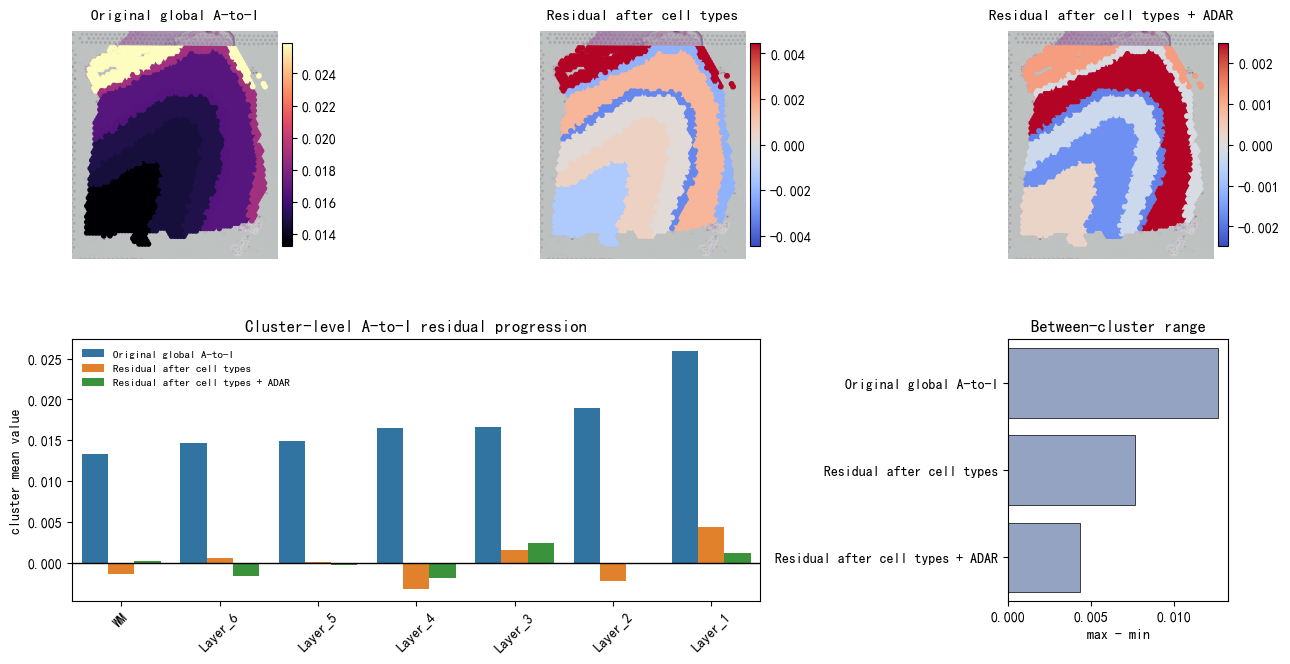

,group,metric,key,value
0,Layer_1,Original global A-to-I,global_atoi_score,0.025880
1,Layer_2,Original global A-to-I,global_atoi_score,0.018967
2,Layer_3,Original global A-to-I,global_atoi_score,0.016646
3,Layer_4,Original global A-to-I,global_atoi_score,0.016526
4,Layer_5,Original global A-to-I,global_atoi_score,0.014938
5,Layer_6,Original global A-to-I,global_atoi_score,0.014602
6,WM,Original global A-to-I,global_atoi_score,0.013255
7,Layer_1,Residual after cell types,global_atoi_residual_celltype,0.004442
8,Layer_2,Residual after cell types,global_atoi_residual_celltype,-0.002184
9,Layer_3,Residual after cell types,global_atoi_residual_celltype,0.001557


In [25]:
required_residual_cols = {
    "global_atoi_score",
    "global_atoi_residual_celltype",
    "global_atoi_residual_celltype_adar",
}

if required_residual_cols.issubset(adata_ai.obs.columns):

    fig, axes, residual_progression_summary = atoi.plot_residual_progression(
        adata_ai,
        keys=(
            "global_atoi_score",
            "global_atoi_residual_celltype",
            "global_atoi_residual_celltype_adar",
        ),
        titles=(
            "Original global A-to-I",
            "Residual after cell types",
            "Residual after cell types + ADAR",
        ),
        group_key=GROUP_KEY,
        kind="bar",
        figsize=(13, 7.2),
    )

    plt.show()
    display(residual_progression_summary)

else:
    print("Residual columns missing:")
    print(required_residual_cols - set(adata_ai.obs.columns))


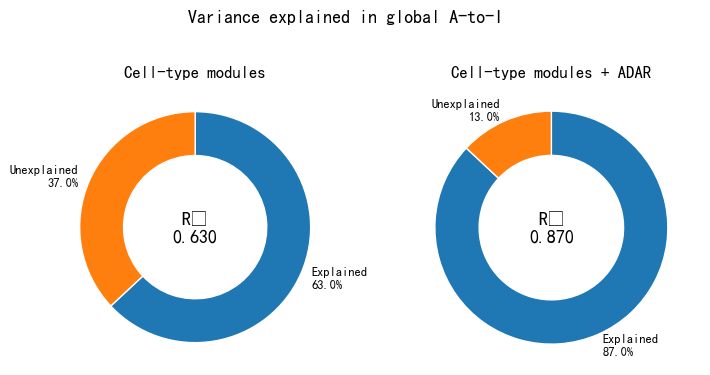

,model,R2,adjusted_R2,Unexplained,method
0,Cell-type modules,0.630417,0.445626,0.369583,model_summary
1,Cell-type modules + ADAR,0.869656,0.739311,0.130344,model_summary


Spot-level Moran's I for global A-to-I:


,value_key,level,group_key,cluster_agg,spatial_k,permutations,random_state,n_units,n_units_total,moran_I,moran_p,geary_C,geary_p,moran_fdr,geary_fdr,sample_id
0,global_atoi_score,spot,NaN,NaN,6,999,0,3612,3639,-0.014873,0.022,1.058859,0.004,0.022,0.004,151673


In [26]:

fig, axes, r2_summary = atoi.plot_global_atoi_two_r2_donuts(
    adata_ai,
    celltype_store_key="cluster_celltype_only_global_atoi_model",
    joint_store_key="cluster_joint_global_atoi_model",
    use_model_summary=True,
    titles=("Cell-type modules", "Cell-type modules + ADAR"),
    figsize=(7.4, 3.6),
)
plt.show()
display(r2_summary)



global_spot_moran = atoi.compute_obs_spatial_autocorrelation(
    adata_ai,
    value_keys=("global_atoi_score",),
    level="spot",
    spatial_k=6,
    permutations=999,
    store_key="global_atoi_spot_moran",
)
global_spot_moran = global_spot_moran.copy()
global_spot_moran["sample_id"] = sample_id

global_moran_records = [
    r for r in global_moran_records
    if r.get("sample_id") != sample_id
]
global_moran_records.extend(global_spot_moran.to_dict("records"))

print("Spot-level Moran's I for global A-to-I:")
display(global_spot_moran)


### Candidate SV-A-to-I sites, WM-associated program, and supplementary annotation


#### Find spatially variable A-to-I sites: binomial + Gaussian spatial model


In [27]:

if "supplementary_sv_tables" not in globals():
    supplementary_sv_tables = {}
if "supplementary_annotation_done" not in globals():
    supplementary_annotation_done = set()
supplementary_sv_tables.pop(str(sample_id), None)
supplementary_annotation_done.discard(str(sample_id))


for _name in ("sv_top_site_records", "wm_enrichment_records", "sv_annotation_records",
              "external_overlap_records", "external_overlap_summary_records", "mechanism_context_records"):
    globals()[_name] = [r for r in globals().get(_name, []) if r.get("sample_id") != sample_id]

sv_atoi = atoi.detect_spatial_atoi_sites_counts(
    adata_ai,
    n_knots="auto",  
    knot_candidates=(0, 1, 2, 3, 4, 5, 6),
    spatial_coords=tissue_positions.reindex(adata_ai.obs_names)[["x_pixel", "y_pixel"]].to_numpy(dtype=float),
    min_cov=5,
    min_valid_spots=20,
    min_total_A=10,
    min_total_G=10,
    sv_call_by="p", 
    p_cutoff=0.05,
    verbose=True,
)

supplementary_sv_tables[str(sample_id)] = sv_atoi.copy()

print("Selected K:", adata_ai.uns["sv_atoi_model_config"]["selected_n_knots"])
if "sv_atoi_k_selection" in adata_ai.uns:
    display(adata_ai.uns["sv_atoi_k_selection"])
display(sv_atoi.head(20))
display(sv_atoi["fit_status"].value_counts(dropna=False))
display(sv_atoi[["pass_qc", "is_sv_atoi"]].value_counts(dropna=False))


top_sv_table = atoi.summarize_top_sv_atoi_sites(
    sv_atoi,
    top_n=20,
    require_sv=True,
    store_in=adata_ai,
    store_key="top_sv_atoi_sites",
)

if top_sv_table.empty:
    print("No called SV-A-to-I sites under the current rule; showing top QC-passing spatial sites instead.")
    top_sv_table = atoi.summarize_top_sv_atoi_sites(
        sv_atoi,
        top_n=20,
        require_sv=False,
        store_in=adata_ai,
        store_key="top_sv_atoi_sites",
    )

top_sv_table = top_sv_table.copy()
top_sv_table["sample_id"] = sample_id
sv_top_site_records = [
    r for r in sv_top_site_records
    if r.get("sample_id") != sample_id
]
sv_top_site_records.extend(top_sv_table.to_dict("records"))

print("Top SV-A-to-I site table:")
display(top_sv_table)


BIC selection: fitting K=0
BIC selection: fitting K=1
BIC selection: fitting K=2
BIC selection: fitting K=3
BIC selection: fitting K=4
BIC selection: fitting K=5
BIC selection: fitting K=6
Selected shared K=6 from 203 common sites; p values conditional on selected K.
Selected K: 6


,n_knots,n_selection_sites,total_bic,selected
0,0,203,153590.278326,False
1,1,203,151802.596460,False
2,2,203,149543.749698,False
3,3,203,147562.293903,False
4,4,203,145753.380001,False
5,5,203,143063.081518,False
6,6,203,140150.438341,True


,site,gene,n_valid_spots,total_A_valid,total_G_valid,total_cov_valid,mean_ratio,sd_ratio,pass_qc,fit_status,...,loglik_spatial,spatial_fdr,is_sv_atoi,sv_call_by,p_cutoff,fdr_cutoff,model_family,selected_n_knots,p_method,k_selection_site
0,14_74058241,ALDH6A1,63,1084.0,225.0,1309.0,0.175596,0.369626,True,ok,...,-376.429461,1.229980e-80,True,spatial_p,0.05,0.05,binomial,6,asymptotic_chi2_conditional_on_selected_k,True
1,10_87208319,SHLD2;NUTM2A,68,1079.0,258.0,1337.0,0.188419,0.388171,True,ok,...,-460.576462,2.607393e-74,True,spatial_p,0.05,0.05,binomial,6,asymptotic_chi2_conditional_on_selected_k,True
2,10_87208329,SHLD2;NUTM2A,72,961.0,558.0,1519.0,0.416351,0.492640,True,ok,...,-818.139873,2.400953e-69,True,spatial_p,0.05,0.05,binomial,6,asymptotic_chi2_conditional_on_selected_k,True
3,7_97922938,CZ1P-ASNS,57,316.0,303.0,619.0,0.450449,0.489677,True,ok,...,-258.780693,3.864923e-63,True,spatial_p,0.05,0.05,binomial,6,asymptotic_chi2_conditional_on_selected_k,True
4,7_97922970,CZ1P-ASNS,30,381.0,80.0,461.0,0.200000,0.400000,True,ok,...,-56.678844,1.084716e-60,True,spatial_p,0.05,0.05,binomial,6,asymptotic_chi2_conditional_on_selected_k,True
5,7_102637202,POLR2J2;UPK3BL1,411,6970.0,84.0,7054.0,0.007048,0.082294,True,ok,...,-283.614451,4.002171e-60,True,spatial_p,0.05,0.05,binomial,6,asymptotic_chi2_conditional_on_selected_k,True
6,10_87208367,SHLD2;NUTM2A,67,1669.0,85.0,1754.0,0.046642,0.206963,True,ok,...,-185.602519,2.468054e-59,True,spatial_p,0.05,0.05,binomial,6,asymptotic_chi2_conditional_on_selected_k,True
7,19_40567138,SPTBN4,65,1058.0,36.0,1094.0,0.015385,0.123077,True,ok,...,-23.724112,9.161396e-52,True,spatial_p,0.05,0.05,binomial,6,asymptotic_chi2_conditional_on_selected_k,False
8,10_87208358,SHLD2;NUTM2A,67,1719.0,143.0,1862.0,0.082216,0.267818,True,ok,...,-333.440270,7.431732e-51,True,spatial_p,0.05,0.05,binomial,6,asymptotic_chi2_conditional_on_selected_k,True
9,1_28509422,SNHG3,46,1009.0,142.0,1151.0,0.152174,0.359189,True,ok,...,-301.592042,3.065377e-49,True,spatial_p,0.05,0.05,binomial,6,asymptotic_chi2_conditional_on_selected_k,True


insufficient_counts                                       5567
fit_failed: coefficient boundary / possible separation     277
ok                                                         219
insufficient_spots_for_model                               180
Name: fit_status, dtype: int64

pass_qc  is_sv_atoi
False    False         5747
True     False          291
         True           205
dtype: int64

Top SV-A-to-I site table:


,rank,site,gene,n_valid_spots,total_A_valid,total_G_valid,total_cov_valid,mean_ratio,sd_ratio,pass_qc,...,spatial_fdr,is_sv_atoi,sv_call_by,p_cutoff,fdr_cutoff,model_family,selected_n_knots,p_method,k_selection_site,sample_id
0,1,14_74058241,ALDH6A1,63,1084.0,225.0,1309.0,0.175596,0.369626,True,...,1.229980e-80,True,spatial_p,0.05,0.05,binomial,6,asymptotic_chi2_conditional_on_selected_k,True,151673
1,2,10_87208319,SHLD2;NUTM2A,68,1079.0,258.0,1337.0,0.188419,0.388171,True,...,2.607393e-74,True,spatial_p,0.05,0.05,binomial,6,asymptotic_chi2_conditional_on_selected_k,True,151673
2,3,10_87208329,SHLD2;NUTM2A,72,961.0,558.0,1519.0,0.416351,0.492640,True,...,2.400953e-69,True,spatial_p,0.05,0.05,binomial,6,asymptotic_chi2_conditional_on_selected_k,True,151673
3,4,7_97922938,CZ1P-ASNS,57,316.0,303.0,619.0,0.450449,0.489677,True,...,3.864923e-63,True,spatial_p,0.05,0.05,binomial,6,asymptotic_chi2_conditional_on_selected_k,True,151673
4,5,7_97922970,CZ1P-ASNS,30,381.0,80.0,461.0,0.200000,0.400000,True,...,1.084716e-60,True,spatial_p,0.05,0.05,binomial,6,asymptotic_chi2_conditional_on_selected_k,True,151673
5,6,7_102637202,POLR2J2;UPK3BL1,411,6970.0,84.0,7054.0,0.007048,0.082294,True,...,4.002171e-60,True,spatial_p,0.05,0.05,binomial,6,asymptotic_chi2_conditional_on_selected_k,True,151673
6,7,10_87208367,SHLD2;NUTM2A,67,1669.0,85.0,1754.0,0.046642,0.206963,True,...,2.468054e-59,True,spatial_p,0.05,0.05,binomial,6,asymptotic_chi2_conditional_on_selected_k,True,151673
7,8,19_40567138,SPTBN4,65,1058.0,36.0,1094.0,0.015385,0.123077,True,...,9.161396e-52,True,spatial_p,0.05,0.05,binomial,6,asymptotic_chi2_conditional_on_selected_k,False,151673
8,9,10_87208358,SHLD2;NUTM2A,67,1719.0,143.0,1862.0,0.082216,0.267818,True,...,7.431732e-51,True,spatial_p,0.05,0.05,binomial,6,asymptotic_chi2_conditional_on_selected_k,True,151673
9,10,1_28509422,SNHG3,46,1009.0,142.0,1151.0,0.152174,0.359189,True,...,3.065377e-49,True,spatial_p,0.05,0.05,binomial,6,asymptotic_chi2_conditional_on_selected_k,True,151673


##### vis

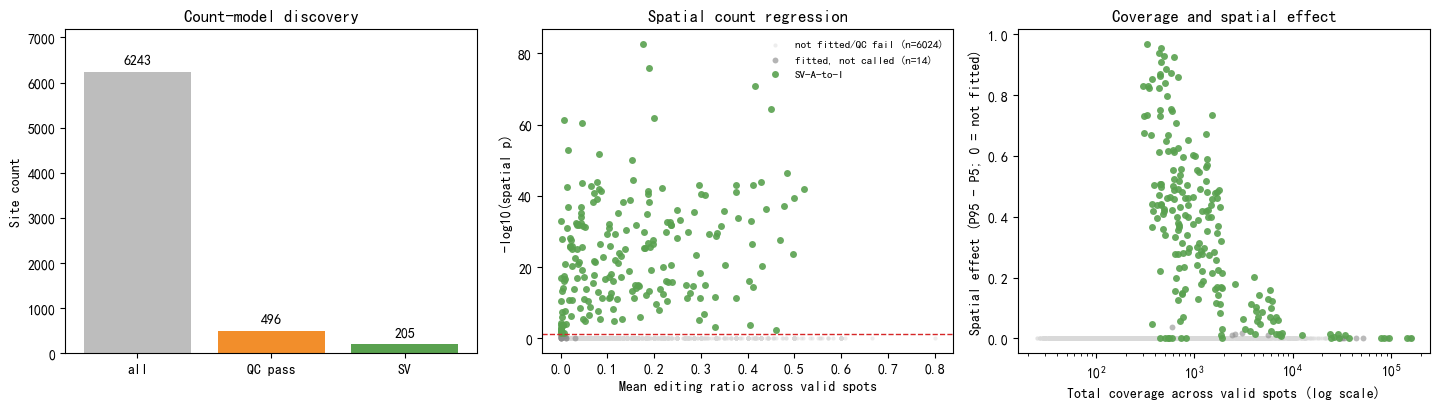

In [28]:
fig, axes = atoi.plot_count_spatial_discovery(
    sv_atoi,
)

plt.show()


#### Compute SV-A-to-I score

SV-A-to-I score sites: 205


,site,gene,is_sv_atoi,score_site_source,spatial_effect,spatial_p,spatial_fdr
0,14_74058241,ALDH6A1,True,called_sv_atoi,0.670326,2.479797e-83,1.229980e-80
1,10_87208319,SHLD2;NUTM2A,True,called_sv_atoi,0.481748,1.051368e-76,2.607393e-74
2,10_87208329,SHLD2;NUTM2A,True,called_sv_atoi,0.732949,1.452189e-71,2.400953e-69
3,7_97922938,CZ1P-ASNS,True,called_sv_atoi,0.926409,3.116873e-65,3.864923e-63
4,7_97922970,CZ1P-ASNS,True,called_sv_atoi,0.955729,1.093464e-62,1.084716e-60
5,7_102637202,POLR2J2;UPK3BL1,True,called_sv_atoi,0.059009,4.841336e-62,4.002171e-60
6,10_87208367,SHLD2;NUTM2A,True,called_sv_atoi,0.226017,3.483141e-61,2.468054e-59
7,19_40567138,SPTBN4,True,called_sv_atoi,0.128825,1.477645e-53,9.161396e-52
8,10_87208358,SHLD2;NUTM2A,True,called_sv_atoi,0.320566,1.348500e-52,7.431732e-51
9,1_28509422,SNHG3,True,called_sv_atoi,0.489680,6.180196e-51,3.065377e-49


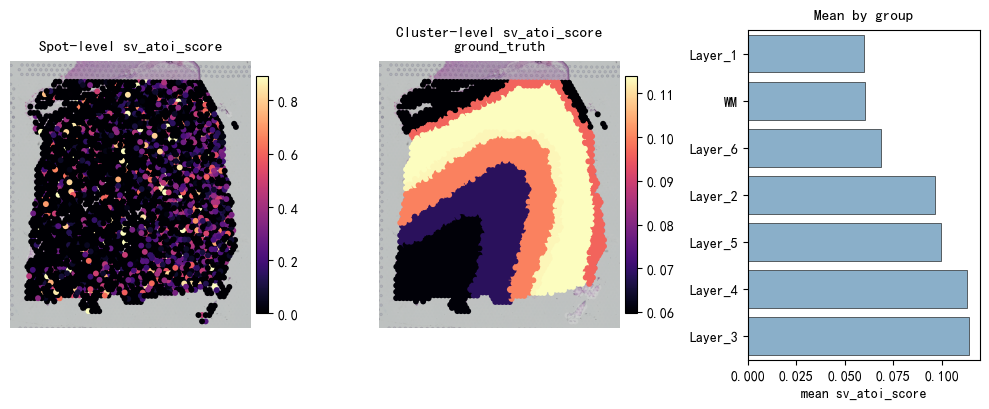

,count,mean,median,std
group,,,,
Layer_1,245,0.059636,0.0,0.173869
WM,499,0.060345,0.0,0.170299
Layer_6,658,0.068409,0.0,0.168902
Layer_2,249,0.096266,0.0,0.184558
Layer_5,671,0.099689,0.0,0.200489
Layer_4,218,0.112934,0.0,0.213327
Layer_3,986,0.113934,0.0,0.195060


In [29]:

for _col in ("sv_atoi_score", "sv_atoi_score_n_sites"):
    if _col in adata_ai.obs:
        del adata_ai.obs[_col]
adata_ai.uns.pop("sv_atoi_score_site_table", None)
try:
    sv_score, sv_score_sites = atoi.compute_sv_atoi_score(
        adata_ai,
        sv_atoi=sv_atoi,
        score_name="sv_atoi_score",
        min_cov=5,
        top_n=None,
        weight_col="spatial_effect",
        require_sv=True,
        fallback_to_ranked=False,
        zscore_sites=False,
    )

    print("SV-A-to-I score sites:", len(sv_score_sites))
    display(sv_score_sites[["site", "gene", "is_sv_atoi", "score_site_source", "spatial_effect", "spatial_p", "spatial_fdr"]].head(20))

    fig, axes, sv_score_summary = atoi.plot_cluster_level_obs_value(
        adata_ai,
        value_key="sv_atoi_score",
        group_key=GROUP_KEY,
        cmap="magma",
    )

    plt.show()
    display(sv_score_summary)

except ValueError as exc:
    print(f"Skip sv_atoi_score: {exc}")


#### Candidate and recurrent SV-A-to-I single-site spatial patterns


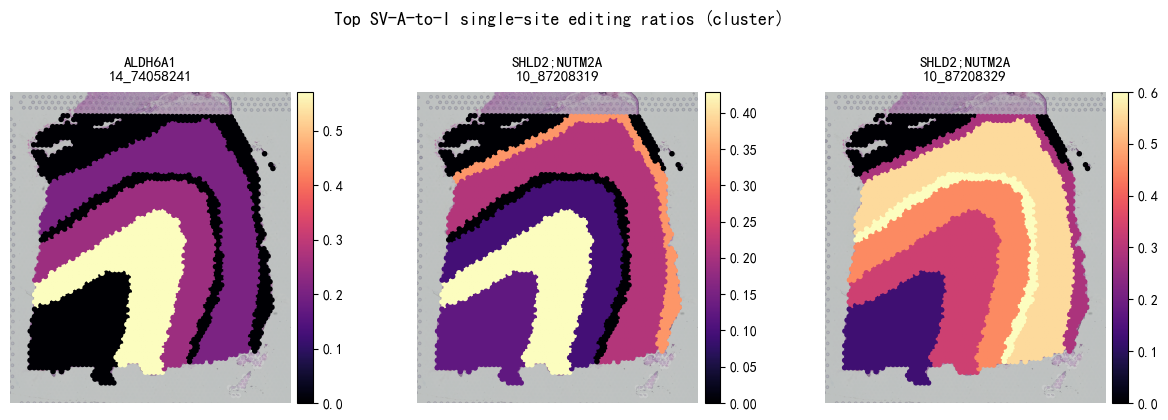

In [30]:

if "is_sv_atoi" in sv_atoi.columns and sv_atoi["is_sv_atoi"].any():

    fig, axes = atoi.plot_top_sv_site_patterns(
        adata_ai,
        sv_atoi=sv_atoi,
        group_key=GROUP_KEY,
        top_n=3,
        min_cov=5,
        mode="cluster",
        cmap="magma",
    )

    plt.show()

else:
    print("No SV-A-to-I sites detected. Skip top-site cluster-level plots.")


#### Global vs SV-A-to-I comparison

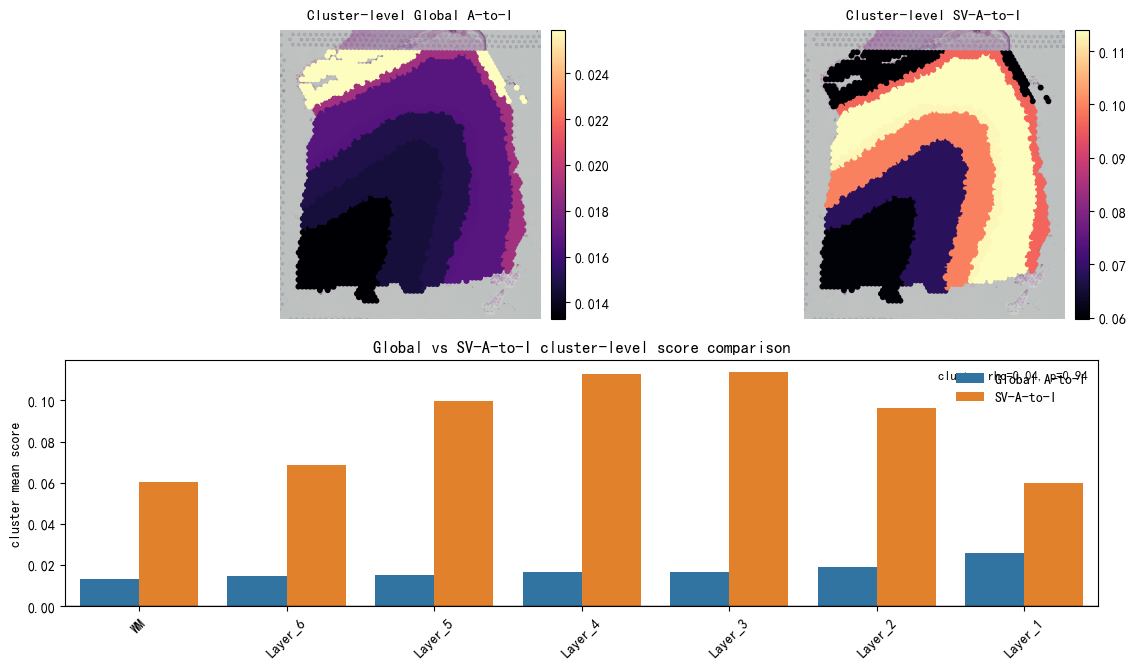

,group,score,score_key,value
0,Layer_1,Global A-to-I,global_atoi_score,0.025880
1,Layer_2,Global A-to-I,global_atoi_score,0.018967
2,Layer_3,Global A-to-I,global_atoi_score,0.016646
3,Layer_4,Global A-to-I,global_atoi_score,0.016526
4,Layer_5,Global A-to-I,global_atoi_score,0.014938
5,Layer_6,Global A-to-I,global_atoi_score,0.014602
6,WM,Global A-to-I,global_atoi_score,0.013255
7,Layer_1,SV-A-to-I,sv_atoi_score,0.059636
8,Layer_2,SV-A-to-I,sv_atoi_score,0.096266
9,Layer_3,SV-A-to-I,sv_atoi_score,0.113934


In [31]:
if "sv_atoi_score" in adata_ai.obs.columns:

    fig, axes, global_sv_summary = atoi.plot_cluster_score_comparison(
        adata_ai,
        score_keys=("global_atoi_score", "sv_atoi_score"),
        titles=("Global A-to-I", "SV-A-to-I"),
        group_key=GROUP_KEY,
        cmap="magma",
        figsize=(11.5, 6.8),
    )

    plt.show()
    display(global_sv_summary)

else:
    print("sv_atoi_score was not computed; skip global vs SV-A-to-I comparison.")


#### Single-slice WM-aware SV-A-to-I analysis

All SV-A-to-I sites called in this slice are tested at spot level with a grouped-binomial model. The signed significance plot classifies WM-high and non-WM-high sites using within-slice BH-FDR < 0.05; log2FC is used only for direction. Sites with zero aggregate A or G reads in either WM or non-WM are retained and marked as `zero_count_boundary`, but are excluded from the Top 3 cluster-level spatial editing-ratio maps because their unpenalized log-odds estimates are unstable.


Single-slice WM-aware grouped-binomial tests for all SV-A-to-I sites called in this slice
151673: tested 205 called SV-A-to-I sites; 31 have positive WM effect and within-slice binomial FDR < 0.05.


,site,sample_id,n_wm_spots,n_nonwm_spots,wm_A,wm_G,nonwm_A,nonwm_G,zero_count_boundary,boundary_reason,...,wm_log_odds,wm_log2fc,wm_log2fc_se,wm_log2fc_ci_low,wm_log2fc_ci_high,wm_odds_ratio,binomial_lrt,binomial_p,binomial_fdr_within_slice,binomial_candidate
1,10_15075711,151673,8,90,47.0,85.0,900.0,677.0,False,,...,0.877227,1.265571,0.272320,0.731824,1.799318,2.404224e+00,22.669976,1.923500e-06,8.014583e-06,True
4,10_15075729,151673,8,88,73.0,50.0,1059.0,443.0,False,,...,0.493074,0.711356,0.277134,0.168174,1.254537,1.637342e+00,6.379110,1.154713e-02,1.950529e-02,True
6,10_15075744,151673,8,83,70.0,33.0,1369.0,95.0,False,,...,1.915971,2.764162,0.340932,2.095935,3.432390,6.793534e+00,53.946226,2.060524e-13,1.981273e-12,True
7,10_15075794,151673,5,66,17.0,17.0,732.0,343.0,False,,...,0.758050,1.093635,0.503764,0.106257,2.081013,2.134111e+00,4.615203,3.168975e-02,4.754444e-02,True
16,10_87208347,151673,8,62,132.0,67.0,1199.0,280.0,False,,...,0.776344,1.120028,0.236649,0.656197,1.583859,2.173512e+00,20.917198,4.795696e-06,1.763123e-05,True
17,10_87208351,151673,8,62,113.0,101.0,1035.0,529.0,False,,...,0.558901,0.806324,0.212067,0.390673,1.221975,1.748750e+00,14.237540,1.611240e-04,4.110306e-04,True
18,10_87208355,151673,7,58,79.0,123.0,958.0,590.0,False,,...,0.927462,1.338044,0.221288,0.904319,1.771769,2.528084e+00,37.654066,8.447043e-10,6.211061e-09,True
20,10_87208360,151673,7,60,198.0,14.0,1640.0,0.0,True,nonwm_G,...,24.916859,35.947429,20917.081546,-40961.532401,41033.427259,6.626045e+10,61.527664,4.365661e-15,6.821345e-14,True
24,10_87208414,151673,5,46,79.0,42.0,776.0,193.0,False,,...,0.759684,1.095992,0.298947,0.510056,1.681929,2.137601e+00,12.583185,3.892328e-04,8.246457e-04,True
25,10_87208418,151673,5,47,58.0,56.0,736.0,200.0,False,,...,1.267821,1.829080,0.293748,1.253334,2.404825,3.553103e+00,37.237084,1.046055e-09,6.881941e-09,True


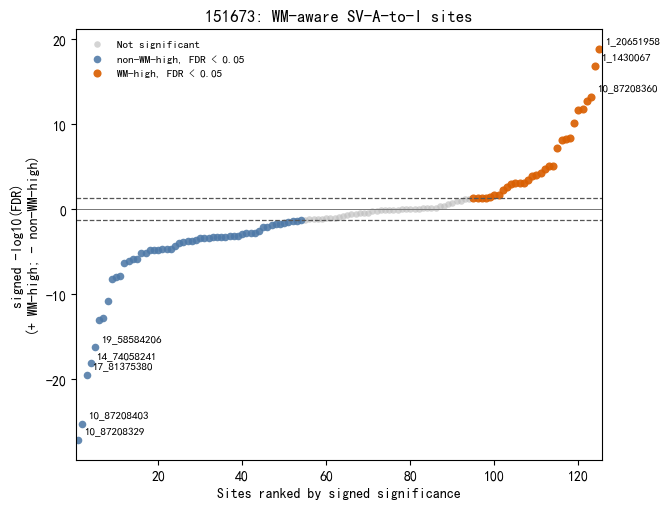

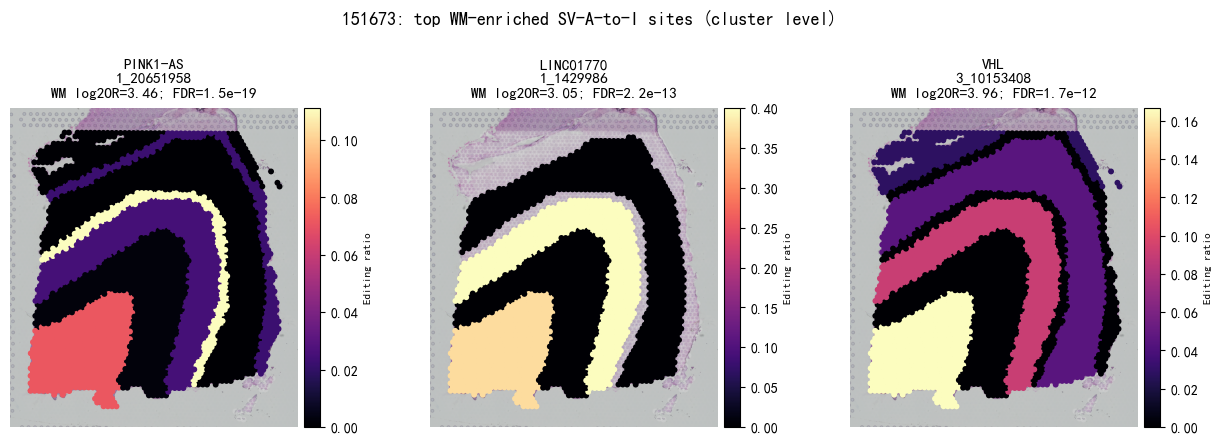

,site,sample_id,n_wm_spots,n_nonwm_spots,wm_A,wm_G,nonwm_A,nonwm_G,zero_count_boundary,boundary_reason,...,wm_log_odds,wm_log2fc,wm_log2fc_se,wm_log2fc_ci_low,wm_log2fc_ci_high,wm_odds_ratio,binomial_lrt,binomial_p,binomial_fdr_within_slice,binomial_candidate
0,1_20651958,151673,28,201,425.0,40.0,3866.0,33.0,False,,...,2.400258,3.462841,0.347191,2.782346,4.143336,11.026025,88.633582,4.751539e-21,1.484856e-19,True
1,1_1429986,151673,21,12,156.0,84.0,184.0,12.0,False,,...,2.110990,3.045515,0.472098,2.120203,3.970827,8.256410,58.604949,1.927311e-14,2.190126e-13,True
2,3_10153408,151673,6,52,38.0,21.0,592.0,21.0,False,,...,2.745920,3.961526,0.506472,2.968840,4.954212,15.578947,54.419448,1.619521e-13,1.687001e-12,True


In [32]:
print("Single-slice WM-aware grouped-binomial tests for all SV-A-to-I sites called in this slice")
_slice_sv_calls = sv_atoi.copy()
_slice_sv_calls["Slice"] = str(sample_id)

try:
    single_slice_sv_wm_binomial, _ = atoi.analyze_recurrent_sv_wm_binomial(
        _slice_sv_calls,
        adata_by_sample={str(sample_id): adata_ai},
        sample_ids=(str(sample_id),),
        sample_col="Slice",
        site_col="site",
        group_key=GROUP_KEY,
        min_cov=5,
        min_spots_per_group=5,
        alpha=0.05,
    )
    single_slice_sv_wm_candidates = single_slice_sv_wm_binomial.loc[
        single_slice_sv_wm_binomial["binomial_candidate"]
    ].copy()

    single_slice_sv_wm_binomial_records = [
        row for row in single_slice_sv_wm_binomial_records
        if str(row.get("sample_id")) != str(sample_id)
    ]
    single_slice_sv_wm_binomial_records.extend(
        single_slice_sv_wm_binomial.to_dict("records")
    )

    print(
        f"{sample_id}: tested {len(single_slice_sv_wm_binomial):,} called SV-A-to-I sites; "
        f"{len(single_slice_sv_wm_candidates):,} have positive WM effect and within-slice binomial FDR < 0.05."
    )
    display(single_slice_sv_wm_candidates)

    fig, ax, single_slice_wm_signed_significance_df = atoi.plot_wm_aware_sv_signed_significance(
        single_slice_sv_wm_binomial,
        fdr_col="binomial_fdr_within_slice",
        effect_col="wm_log2fc",
        candidate_col="binomial_candidate",
        title=f"{sample_id}: WM-aware SV-A-to-I sites",
        label_top_n=8,
        figsize=(6.8, 5.2),
    )
    plt.show()

    if single_slice_sv_wm_candidates.empty:
        print("No significant WM-enriched SV-A-to-I site; skip candidate spatial-ratio maps.")
    else:
        fig, axes, single_slice_wm_spatial_sites = atoi.plot_wm_aware_sv_spatial_ratios(
            adata_ai,
            single_slice_sv_wm_binomial,
            group_key=GROUP_KEY,
            fdr_col="binomial_fdr_within_slice",
            effect_col="wm_log2fc",
            candidate_col="binomial_candidate",
            top_n=3,
            min_cov=5,
            mode="cluster",
            cmap="magma",
            title=f"{sample_id}: top WM-enriched SV-A-to-I sites",
        )
        plt.show()
        display(single_slice_wm_spatial_sites)

except ValueError as exc:
    single_slice_sv_wm_binomial = pd.DataFrame()
    single_slice_sv_wm_candidates = pd.DataFrame()
    print(f"Skip single-slice WM-aware grouped-binomial analysis: {exc}")


#### SV-A-to-I annotation and external overlaps


In [33]:
try:
    sv_annotation = atoi.annotate_sv_atoi_sites(
        adata_ai,
        sv_atoi=sv_atoi,
        top_n=None,
        require_sv=True,
        store_key="sv_atoi_site_annotation",
    )
    sv_annotation = sv_annotation.copy()
    sv_annotation["sample_id"] = sample_id
    sv_annotation_records = [
        r for r in sv_annotation_records
        if r.get("sample_id") != sample_id
    ]
    sv_annotation_records.extend(sv_annotation.to_dict("records"))

    print("Detected SV-A-to-I site annotation table:")
    display(sv_annotation.head(40))

    external_detail, external_summary = atoi.run_sv_external_mechanism_overlaps(
        sv_annotation,
        annotation_paths=EXTERNAL_ANNOTATION_PATHS,
        site_col="site",
        flank=0,
        store_key="sv_external_mechanism_overlaps",
        adata_ai=adata_ai,
    )
    supplementary_annotation_done.add(str(sample_id))
    for _df in [external_detail, external_summary]:
        if not _df.empty:
            _df["sample_id"] = sample_id

    external_overlap_records = [
        r for r in external_overlap_records
        if r.get("sample_id") != sample_id
    ]
    external_overlap_summary_records = [
        r for r in external_overlap_summary_records
        if r.get("sample_id") != sample_id
    ]
    if not external_detail.empty:
        external_overlap_records.extend(external_detail.to_dict("records"))
    if not external_summary.empty:
        external_overlap_summary_records.extend(external_summary.to_dict("records"))

    mechanism_context = atoi.infer_sv_site_mechanism_context(
        sv_annotation,
        external_overlap_detail=external_detail,
        site_col="site",
    )
    if not mechanism_context.empty:
        mechanism_context["sample_id"] = sample_id
    mechanism_context_records = [
        r for r in mechanism_context_records
        if r.get("sample_id") != sample_id
    ]
    if not mechanism_context.empty:
        mechanism_context_records.extend(mechanism_context.to_dict("records"))

    print("External overlap summary. n_site_annotation_links is the sum of matched annotation rows across queried sites; gene-level links may repeat for sites sharing a host gene.")
    display(external_summary)
    positive_external_detail = external_detail.loc[external_detail["overlap"] == True].copy()
    if not positive_external_detail.empty:
        print("Positive external evidence by site (RBP names are IDR-supported and deduplicated):")
        display(positive_external_detail[[c for c in [
            "sample_id", "site", "source", "matched_gene", "overlap_names",
            "n_overlaps", "n_raw_overlaps", "annotation_scope"
        ] if c in positive_external_detail.columns]].head(120))
    print("Mechanism-oriented context for detected SV-A-to-I sites:")
    display(mechanism_context[[c for c in [
        "sample_id", "site", "host_gene", "gene", "Gene.refGene",
        "regulatory_region_class", "mirna_context", "repeat_context",
        "external_overlap_sources", "n_external_evidence_types", "mechanism_class", "mechanism_note"
    ] if c in mechanism_context.columns]].head(80))

except ValueError as exc:
    print(f"Skip SV annotation/external mechanism overlap: {exc}")


Detected SV-A-to-I site annotation table:


,site,gene,n_valid_spots,total_A_valid,total_G_valid,total_cov_valid,mean_ratio,sd_ratio,pass_qc,fit_status,...,selected_n_knots,p_method,k_selection_site,Gene.refGene,Func.refGene,ExonicFunc.refGene,AAChange.refGene,repeat,host_gene,sample_id
0,14_74058241,ALDH6A1,63,1084.0,225.0,1309.0,0.175596,0.369626,True,ok,...,6,asymptotic_chi2_conditional_on_selected_k,True,ALDH6A1,UTR3,-,-,SINE/AluSc8,ALDH6A1,151673
1,10_87208319,SHLD2;NUTM2A,68,1079.0,258.0,1337.0,0.188419,0.388171,True,ok,...,6,asymptotic_chi2_conditional_on_selected_k,True,SHLD2;NUTM2A,intergenic,-,-,SINE/AluSx,SHLD2;NUTM2A,151673
2,10_87208329,SHLD2;NUTM2A,72,961.0,558.0,1519.0,0.416351,0.492640,True,ok,...,6,asymptotic_chi2_conditional_on_selected_k,True,SHLD2;NUTM2A,intergenic,-,-,SINE/AluSx,SHLD2;NUTM2A,151673
3,7_97922938,CZ1P-ASNS,57,316.0,303.0,619.0,0.450449,0.489677,True,ok,...,6,asymptotic_chi2_conditional_on_selected_k,True,CZ1P-ASNS,ncRNA_intronic,-,-,SINE/AluSx,CZ1P-ASNS,151673
4,7_97922970,CZ1P-ASNS,30,381.0,80.0,461.0,0.200000,0.400000,True,ok,...,6,asymptotic_chi2_conditional_on_selected_k,True,CZ1P-ASNS,ncRNA_intronic,-,-,SINE/AluSx,CZ1P-ASNS,151673
5,7_102637202,POLR2J2;UPK3BL1,411,6970.0,84.0,7054.0,0.007048,0.082294,True,ok,...,6,asymptotic_chi2_conditional_on_selected_k,True,POLR2J2;UPK3BL1,UTR3,-,-,SINE/AluSc,POLR2J2;UPK3BL1,151673
6,10_87208367,SHLD2;NUTM2A,67,1669.0,85.0,1754.0,0.046642,0.206963,True,ok,...,6,asymptotic_chi2_conditional_on_selected_k,True,SHLD2;NUTM2A,intergenic,-,-,SINE/AluSx,SHLD2;NUTM2A,151673
7,19_40567138,SPTBN4,65,1058.0,36.0,1094.0,0.015385,0.123077,True,ok,...,6,asymptotic_chi2_conditional_on_selected_k,False,SPTBN4,intronic,-,-,SINE/AluJo,SPTBN4,151673
8,10_87208358,SHLD2;NUTM2A,67,1719.0,143.0,1862.0,0.082216,0.267818,True,ok,...,6,asymptotic_chi2_conditional_on_selected_k,True,SHLD2;NUTM2A,intergenic,-,-,SINE/AluSx,SHLD2;NUTM2A,151673
9,1_28509422,SNHG3,46,1009.0,142.0,1151.0,0.152174,0.359189,True,ok,...,6,asymptotic_chi2_conditional_on_selected_k,True,SNHG3,ncRNA_exonic,-,-,SINE/AluSx3,SNHG3,151673


External overlap summary. n_site_annotation_links is the sum of matched annotation rows across queried sites; gene-level links may repeat for sites sharing a host gene.


,source,annotation_path,annotation_status,available,annotation_scope,n_sites,n_overlap_sites,n_site_annotation_links,n_unique_overlap_labels,overlap_count_definition,sample_id
0,miRBase,D:\data\SPARROW_data\Annotation\miRBase\hsa.gff3,loaded,True,direct_site_overlap,205,0,0,0,sum of matched annotation rows across queried ...,151673
1,miRGeneDB,D:\data\SPARROW_data\Annotation\miRGeneDB\hsa-...,loaded,True,direct_site_overlap,205,0,0,0,sum of matched annotation rows across queried ...,151673
2,RepeatMasker/Alu,D:\data\SPARROW_data\Annotation\RepeatMasker\r...,loaded,True,direct_site_overlap,205,191,191,18,sum of matched annotation rows across queried ...,151673
3,REDIportal,D:\data\SPARROW_data\Annotation\REDIportal\TAB...,loaded,True,direct_site_overlap,205,205,205,205,sum of matched annotation rows across queried ...,151673
4,TargetScan gene information,D:\data\SPARROW_data\Annotation\TargetScan\Gen...,loaded,True,human_gene_reference,205,127,216,37,sum of matched annotation rows across queried ...,151673
5,TargetScan miRNA families,D:\data\SPARROW_data\Annotation\TargetScan\miR...,loaded,True,reference_catalog_not_direct_site_overlap,205,0,0,0,sum of matched annotation rows across queried ...,151673
6,TargetScan predictions,D:\data\SPARROW_data\Annotation\TargetScan\Sum...,loaded,True,human_gene_miRNA_prediction,205,127,45530,234,sum of matched annotation rows across queried ...,151673
7,RBP,D:\data\SPARROW_data\Annotation\RBP\ENCODE_eCL...,loaded,True,ENCODE_eCLIP_IDR_peaks_deduplicated_by_RBP,205,24,54,20,sum of matched annotation rows across queried ...,151673


Positive external evidence by site (RBP names are IDR-supported and deduplicated):


,sample_id,site,source,matched_gene,overlap_names,n_overlaps,n_raw_overlaps,annotation_scope
410,151673,14_74058241,RepeatMasker/Alu,NaN,AluSc8,1,NaN,direct_site_overlap
411,151673,10_87208319,RepeatMasker/Alu,NaN,AluSx,1,NaN,direct_site_overlap
412,151673,10_87208329,RepeatMasker/Alu,NaN,AluSx,1,NaN,direct_site_overlap
413,151673,7_97922938,RepeatMasker/Alu,NaN,AluSx,1,NaN,direct_site_overlap
414,151673,7_97922970,RepeatMasker/Alu,NaN,AluSx,1,NaN,direct_site_overlap
...,...,...,...,...,...,...,...,...
526,151673,11_78068661,RepeatMasker/Alu,NaN,AluSc,1,NaN,direct_site_overlap
527,151673,10_15075826,RepeatMasker/Alu,NaN,AluSx,1,NaN,direct_site_overlap
528,151673,8_56067496,RepeatMasker/Alu,NaN,AluY,1,NaN,direct_site_overlap
529,151673,7_97922868,RepeatMasker/Alu,NaN,AluSx,1,NaN,direct_site_overlap


Mechanism-oriented context for detected SV-A-to-I sites:


,sample_id,site,host_gene,gene,Gene.refGene,regulatory_region_class,mirna_context,repeat_context,external_overlap_sources,n_external_evidence_types,mechanism_class,mechanism_note
0,151673,14_74058241,ALDH6A1,ALDH6A1,ALDH6A1,3UTR,True,Alu/repeat-supported,REDIportal;RepeatMasker/Alu;TargetScan gene in...,3,multi-source evidence,MIR-associated host annotation motivates nonco...
1,151673,10_87208319,SHLD2;NUTM2A,SHLD2;NUTM2A,SHLD2;NUTM2A,intergenic,False,Alu/repeat-supported,REDIportal;RepeatMasker/Alu;TargetScan gene in...,3,multi-source evidence,Repeat/Alu context supports canonical ADAR dsR...
2,151673,10_87208329,SHLD2;NUTM2A,SHLD2;NUTM2A,SHLD2;NUTM2A,intergenic,False,Alu/repeat-supported,REDIportal;RepeatMasker/Alu;TargetScan gene in...,3,multi-source evidence,Repeat/Alu context supports canonical ADAR dsR...
3,151673,7_97922938,CZ1P-ASNS,CZ1P-ASNS,CZ1P-ASNS,ncRNA,False,Alu/repeat-supported,REDIportal;RepeatMasker/Alu,2,multi-source evidence,Repeat/Alu context supports canonical ADAR dsR...
4,151673,7_97922970,CZ1P-ASNS,CZ1P-ASNS,CZ1P-ASNS,ncRNA,False,Alu/repeat-supported,REDIportal;RepeatMasker/Alu,2,multi-source evidence,Repeat/Alu context supports canonical ADAR dsR...
...,...,...,...,...,...,...,...,...,...,...,...,...
75,151673,19_58584206,CENPBD1P1,CENPBD1P1,CENPBD1P1,ncRNA,False,Alu/repeat-supported,REDIportal;RepeatMasker/Alu,2,multi-source evidence,Repeat/Alu context supports canonical ADAR dsR...
76,151673,19_58584089,CENPBD1P1,CENPBD1P1,CENPBD1P1,ncRNA,False,Alu/repeat-supported,REDIportal;RepeatMasker/Alu,2,multi-source evidence,Repeat/Alu context supports canonical ADAR dsR...
77,151673,1_20651958,PINK1-AS,PINK1-AS,PINK1-AS,ncRNA,False,Alu/repeat-supported,RBP;REDIportal;RepeatMasker/Alu,3,multi-source evidence,Repeat/Alu context supports canonical ADAR dsR...
78,151673,17_16441790,SNHG29,SNHG29,SNHG29,ncRNA,False,Alu/repeat-supported,RBP;REDIportal;RepeatMasker/Alu,3,multi-source evidence,Repeat/Alu context supports canonical ADAR dsR...
